In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob, os, yaml, itertools, subprocess, sys, shutil,sparse

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings, pickle
warnings.filterwarnings("ignore")

import matplotlib
from matplotlib.ticker import ScalarFormatter, MaxNLocator

# load all utils functions
os.chdir("../")
who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
who_variants['compatible_variant'] = who_variants['variant'].str.replace('_c.', '_c_').str.replace('_n.', '_n_').str.replace('_p.', '_p_')
who_variants['compatible_variant'] = who_variants['compatible_variant'].str.replace('*', '+')
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

regression_who_results = pd.read_csv("/home/sak0914/who-analysis/results/Regression_Final_June2024_Tier1.csv")

sys.path.append("utils")
from data_utils import *
from inSilicoMut_utils import *

drug_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
amino_acid_biophysical_properties = pd.read_csv("./data_processing/protein_seqs/biophysical_properties_AA.csv", index_col=[0])

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_full = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_v4.csv")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")
h37Rv_coords_to_gene = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/h37Rv_coords_to_gene.csv")
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))

# yadon_2 = pd.read_excel("analysis/Yadon_Supp_Data2.xlsx", sheet_name=None)

# if len(yadon_2) == 1:
#     yadon_2 = yadon_2[list(yadon_2.keys())[0]]

# # they already removed discrepant mutations from this list
# assert len(yadon_2.loc[(yadon_2['in vitro Resistant']==1) & (yadon_2['in vitro Susceptible']==1)]) == 0
# assert len(yadon_2.loc[(yadon_2['in vivo Resistant']==1) & (yadon_2['in vivo Susceptible']==1)]) == 0

# no_muts = []

# for i, row in yadon_2.iterrows():

#     aa_1 = row['Substitution'][0]
#     aa_2 = row['Substitution'][-1]
#     codon = row['Substitution'][1:-1]

#     # first convert 1-letter to 3-letter abbreviations
#     if '*' not in row['Substitution']:
#         yadon_2.loc[i, 'mutation'] = f"pncA_p_{Bio.SeqUtils.IUPACData.protein_letters_1to3[aa_1]}{codon}{Bio.SeqUtils.IUPACData.protein_letters_1to3[aa_2]}"
#     elif aa_1 != '*' and aa_2 == '*':
#         yadon_2.loc[i, 'mutation'] = f"pncA_p_{Bio.SeqUtils.IUPACData.protein_letters_1to3[aa_1]}{codon}+"

#     if row['in vitro Resistant'] == 1 or row['in vivo Resistant'] == 1:
#         yadon_2.loc[i, 'phenotype'] = 1
#     elif row['in vitro Susceptible'] == 1 or row['in vivo Susceptible'] == 1:
#         yadon_2.loc[i, 'phenotype'] = -1
#     else:
#         # do not affect R or S
#         for col_name in ['in vitro Resistant', 'in vivo Resistant', 'in vitro Susceptible', 'in vivo Susceptible']:
#             assert pd.isnull(row[col_name])
                             
#         yadon_2.loc[i, 'phenotype'] = 0

#     if aa_1 == aa_2:
#         no_muts.append(yadon_2['mutation'].values[i])

# yadon_2 = yadon_2.query("mutation not in @no_muts")
# yadon_2['phenotype'] = yadon_2['phenotype'].astype(int)

# start_codons = ['ATG', 'CTG', 'GTG', 'TTG', 'ATA', 'ATC', 'ATT']

# start_changes = ['CTG', 'GTG', 'TTG', 'AAG', 'ACG', 'AGG', 'ATA', 'ATC', 'ATT']
# [str(Seq.Seq(codon).translate()) for codon in start_changes]
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETH': 5, 'MXF': 0.5, 'LEV': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv").dropna(subset='variant').reset_index(drop=True)

In [91]:
new_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results_old"

for drug in os.listdir(data_dir):

    if drug == 'ETH':

        old_fNames = glob.glob(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{drug}_tier2_amino_acid/*")
        old_fNames = [fName for fName in old_fNames if os.path.isfile(fName)]

        if not os.path.isdir(f"{new_dir}/{drug}_tier2_amino_acid"):
            os.mkdir(f"{new_dir}/{drug}_tier2_amino_acid")

        for fName in old_fNames:
            if os.path.isfile(fName):
                os.rename(fName, f"{new_dir}/{drug}_tier2_amino_acid/{os.path.basename(fName)}")

        new_fNames = glob.glob(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{drug}_tier2_amino_acid/.snapshot/data1_2024-08-06_17_20_03_UTC/*")
        new_fNames = [fName for fName in new_fNames if os.path.isfile(fName)]

        for fName in new_fNames:
            if os.path.isfile(fName) and '_old' not in fName:
                subprocess.run(f"cp -p {fName} {fName.replace('/.snapshot/data1_2024-08-06_17_20_03_UTC', '')}", shell=True)

# Analysis of in silico mutagenesis

# 1. Plot ECDFs for Global Check

In [3]:
def plot_ECDF(model_path, cc, log_base=2, V1=False, include_uncertain=True, saveFig=False, show=False):

    drug = model_path.split("_")[0]
    full_drug_name = abbr_drug_dict[drug]

    # need to get predictions for all mutations across all loci
    dfs_lst = []

    for fName in glob.glob(os.path.join(results_dir, model_path, "inSilico_analysis", "*", "*test_predictions.csv")):

        df = pd.read_csv(fName).rename(columns={'ROLLINGDB_ID': 'mutation'})

        df = df.merge(who_variants.query("drug==@full_drug_name")[['compatible_variant', 'effect']], left_on='mutation', right_on='compatible_variant', how='left')

        # add critical concentratio
        df['CC'] = cc_dict[drug]

        # 1 for H37Rv
        assert sum(pd.isnull(df['effect'])) == 1
        del df['compatible_variant']

        df['Locus'] = os.path.basename(os.path.dirname(fName))
        dfs_lst.append(df)

    df = pd.concat(dfs_lst)#.drop_duplicates("mutation", keep="first")

    # check that they all have the same prediction for H37Rv. Higher threshold for PZA
    if drug == 'PZA':
        if df.query("mutation=='MT_H37Rv'").pred_MIC.max() - df.query("mutation=='MT_H37Rv'").pred_MIC.min() > 1e-4:
            raise ValueError(f"Problem with {model_path} predictions")
    else:
        if df.query("mutation=='MT_H37Rv'").pred_MIC.max() - df.query("mutation=='MT_H37Rv'").pred_MIC.min() > 1e-6:
            raise ValueError(f"Problem with {model_path} predictions")
        
    # put in same format as the in silico mutations to subset
    if V1:
        catalog_variants = who_variants_V1.copy().query("drug==@drug")
    else:
        catalog_variants = who_variants_V2.copy().rename(columns={'FINAL CONFIDENCE GRADING': 'confidence'}).loc[who_variants_V2['drug']==abbr_drug_dict[drug]]
    
    catalog_variants['mutation'] = [val.replace('_c.', '_c_').replace('_p.', '_p_').replace('_n.', '_n_').replace('*', '+') for val in catalog_variants['variant'].values]
    h37Rv_pred = df.query("mutation=='MT_H37Rv'").pred_MIC.values[0]
    # print(f"H37Rv prediction: {np.round(h37Rv_pred, 2)} µg/mL")
    
    # get confidences. This also keeps only the mutations in that version of the catalog
    df = df.merge(catalog_variants[['mutation', 'confidence']], on='mutation', how='left')

    # assert sum(pd.isnull(df['confidence'])) == 0

    # when the same variant is tested in multiple loci (because it's in an overlapping upstream region), keep the prediction that's farther away from the H37Rv prediction
    df['ref_pred'] = h37Rv_pred
    # df['diff_from_ref'] = np.abs(df['pred_MIC'] - df['ref_pred'])
    df['fold_change'] = df['pred_MIC'] / df['ref_pred']
    df['log_fold_change'] = np.log(df['fold_change'])
    
    df = df.sort_values(['mutation', 'fold_change'], ascending=[True, False]).drop_duplicates('mutation', keep='first')

    if not include_uncertain:
        plot_df = df.query("mutation != 'MT_H37Rv' & confidence != '3) Uncertain significance'")
    else:
        plot_df = df.query("mutation != 'MT_H37Rv'")

    # print(plot_df.groupby("confidence")['pred_MIC'].agg(['mean', 'median']))
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.ecdfplot(data=plot_df, 
                 x='pred_MIC', 
                 hue="confidence", 
                 hue_order=np.sort(plot_df["confidence"].unique()),
                 palette=dict(zip(['1) Assoc w R', '2) Assoc w R - Interim', '3) Uncertain significance', '4) Not assoc w R - Interim', '5) Not assoc w R'], sns.color_palette("colorblind").as_hex())),
                 ax=ax,
                 log_scale=log_base, # for PZA, set to 10 to spread out the graph
                 zorder=3
                )
    
    # ax.set_yticks(ticks=ax.get_yticks(), labels=(ax.get_yticks()*100).astype(int))
    ax.set_yticks(ticks=[0.25, 0.5, 0.75, 1], labels=[25, 50, 75, 100])

    for percentile in [0.25, 0.5, 0.75]:
        plt.axhline(y=percentile, linestyle='--', color="lightgray", linewidth=1, zorder=0)

    # plt.axvline(x=cc, linestyle='--', color="black", linewidth=1, zorder=0, label=f"CC = {cc} µg/mL")
    plt.xlabel(f"{abbr_drug_dict[drug]} MIC (µg/mL)",  fontsize=8)
    plt.ylabel("Percentile",  fontsize=8)
    plt.title(f"Predicted MICs of {plot_df.mutation.nunique()} WHO Catalog Mutations\n", fontsize=10)
    
    y = plot_df['pred_MIC']
    plt.xlim(y.min()*1.1, y.max()*1.1)

    sns.move_legend(ax, fontsize=7, title='', ncol=1, loc='upper right', bbox_to_anchor=(1.45, 0.6))
    # sns.move_legend(ax, fontsize=6, title='', ncol=5, loc='upper right', bbox_to_anchor=(1, -0.15))#, bbox_to_anchor=(1.5, 0.6))
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine()
    
    if saveFig:
        if not os.path.isdir(f"results/{abbr_drug_dict[drug]}"):
            os.makedirs(f"results/{abbr_drug_dict[drug]}")
            
        plt.savefig(f"results/{abbr_drug_dict[drug]}/insilico_ECDF.svg", format='svg', bbox_inches='tight')
        plt.close()
    else:
        if show:
            plt.show()
        else:
            plt.close()

    if 'category' in df.columns:
        del df['category']
        
    return df.reset_index(drop=True)

In [157]:
all_drugs_insilico_pred = []

for drug in os.listdir(data_dir):

    # because lineage worsens the PZA CNN
    if drug == 'PZA':
        model_path = f"{drug}_amino_acid"
    # elif drug == 'ETH':
    #     model_path = f"{drug}_lineage_tier2_amino_acid"
    else:
        model_path = f"{drug}_lineage_amino_acid"

    if drug == 'PZA':
        log_base = 10
    else:
        log_base = 2
        
    df = plot_ECDF(model_path, cc_dict[drug], log_base=log_base, include_uncertain=True, V1=False, saveFig=True, show=True)
    df['gene'] = df['mutation'].str.split('_').str[0]
    df.loc[df['mutation']=='MT_H37Rv', 'gene'] = 'MT_H37Rv'
    df['drug'] = drug

    kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", 'r'))

    print(drug)
    print(np.sort(df.gene.unique()))
    print(np.sort(np.array(kwargs['tier1_loci'])))
    
    all_drugs_insilico_pred.append(df)

all_drugs_insilico_pred = pd.concat(all_drugs_insilico_pred)

silent_variants_insilico_pred = all_drugs_insilico_pred.query("effect in @silent_lst")

BDQ
['MT_H37Rv' 'Rv0678' 'atpE' 'mmpL5' 'mmpS5' 'pepQ']
['Rv0678' 'atpE' 'mmpLS5' 'pepQ']
EMB
['MT_H37Rv' 'aftB' 'embA' 'embB' 'embC' 'ubiA']
['aftA-embCAB' 'aftB-ubiA']
ETH
['MT_H37Rv' 'ethA' 'ethR' 'inhA' 'mshA']
['ethA' 'ethR' 'fabG1-inhA' 'mshA']
INH
['MT_H37Rv' 'ahpC' 'inhA' 'katG']
['ahpC' 'fabG1-inhA' 'kasA' 'katG-furA']
LEV
['MT_H37Rv' 'gyrA' 'gyrB']
['gyrBA']
MXF
['MT_H37Rv' 'gyrA' 'gyrB']
['gyrBA']
PZA
['MT_H37Rv' 'clpC1' 'panD' 'pncA' 'rpsA']
['clpC1' 'panD' 'pncA' 'rpsA']
RIF
['MT_H37Rv' 'rpoB' 'rpoC']
['rpoBC']


In [158]:
ethA_nonsense = all_drugs_insilico_pred.query("drug=='ETH' & gene=='ethA' & mutation.str.contains('\+')")
ethA_nonsense_pred_R = ethA_nonsense.query("pred_MIC >= 5")
ethA_nonsense_pred_S = ethA_nonsense.query("pred_MIC < ref_pred")

print(f"{len(ethA_nonsense)} ethA nonsense mutations")
print(f"{len(ethA_nonsense_pred_R)}/{len(ethA_nonsense)} ({np.round(len(ethA_nonsense_pred_R)/len(ethA_nonsense)*100, 1)})% ethA nonsense mutations are predicted to cause resistance")
print(f"{len(ethA_nonsense_pred_S)}/{len(ethA_nonsense)} ({np.round(len(ethA_nonsense_pred_S)/len(ethA_nonsense)*100, 1)})% ethA nonsense mutations are predicted to cause susceptibility")

63 ethA nonsense mutations
1/63 (1.6)% ethA nonsense mutations are predicted to cause resistance
4/63 (6.3)% ethA nonsense mutations are predicted to cause susceptibility


# Summary of log-transformed fold change (relative to H37Rv) for all groups/drugs

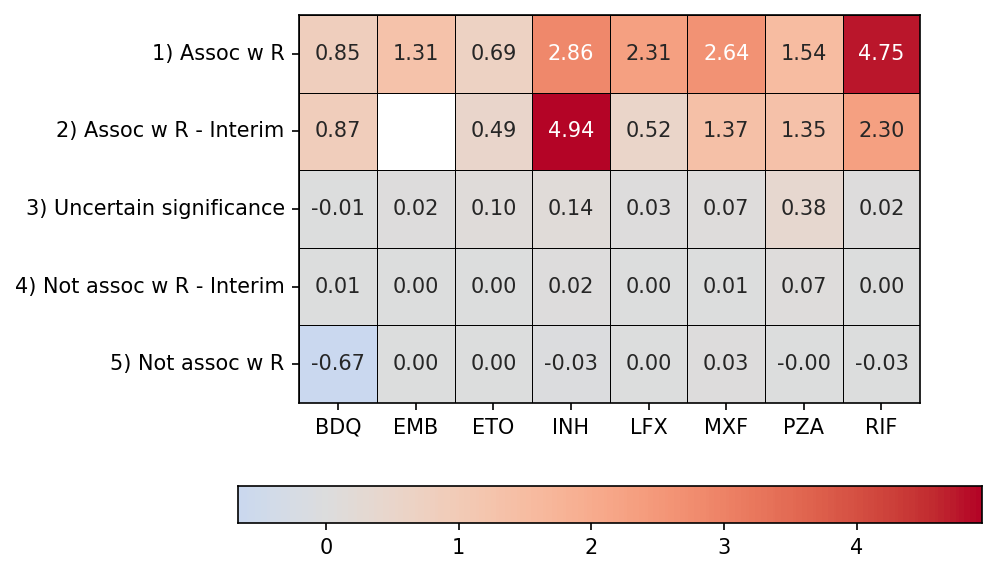

In [159]:
summary_catalog_groups_MICs = []

for drug in all_drugs_insilico_pred.drug.unique():

    df_single_drug = all_drugs_insilico_pred.query("drug==@drug & mutation != 'MT_H37Rv'")
    df_summary = pd.DataFrame(df_single_drug.groupby('confidence')['log_fold_change'].mean()).reset_index()
    df_summary['Drug'] = drug
    summary_catalog_groups_MICs.append(df_summary)

summary_catalog_groups_MICs = pd.concat(summary_catalog_groups_MICs)
summary_catalog_groups_MICs = summary_catalog_groups_MICs.pivot(index='confidence', columns='Drug', values='log_fold_change')
summary_catalog_groups_MICs.rename(columns={'ETH': 'ETO', 'LEV': 'LFX'}, inplace=True)

max_val = np.max(np.abs(summary_catalog_groups_MICs.fillna(0).values))

min_val = summary_catalog_groups_MICs.fillna(0).values.min()
max_val = summary_catalog_groups_MICs.fillna(0).values.max()

sns.heatmap(summary_catalog_groups_MICs,
            vmin=min_val,
            vmax=max_val,
            center=0,
            annot=True,
            fmt='.2f',
            linewidths=0.3,
            linecolor='black',
            cbar=True,
            cmap='coolwarm',
            square=True,
            cbar_kws={"orientation": "horizontal"}
           )

plt.xlabel('')
plt.ylabel('')
sns.despine(top=False, right=False, left=False, bottom=False)
plt.savefig("results/insilicio_mut_fold_change_summary.svg", bbox_inches='tight')

# Any silent variants predicted to cause resistance?

In [160]:
silent_variants_insilico_pred.query("pred_MIC > CC").sort_values("fold_change", ascending=False)

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug


# Individual Discrepancies / Interesting points to make

# ahpC Mutations (isoniazid)

In [107]:
xpert_lst = np.arange(-92, -47+1).astype(str)

all_drugs_insilico_pred.query("drug=='INH' & gene == 'ahpC' & mutation.str.contains('|'.join(@xpert_lst))").query("pred_MIC > 0.2").sort_values("pred_MIC", ascending=False)

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
16,ahpC_c_-51G>A,1.698340,3.245274,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,65.384311,4.180282,ahpC,INH
22,ahpC_c_-54C>T,0.009988,1.006947,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,20.287514,3.010006,ahpC,INH
17,ahpC_c_-52C>A,-0.518871,0.697918,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,14.061335,2.643429,ahpC,INH
24,ahpC_c_-57C>T,-0.617488,0.651805,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,13.132273,2.575073,ahpC,INH
19,ahpC_c_-52C>T,-1.047807,0.483703,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,9.745429,2.276798,ahpC,INH
21,ahpC_c_-54C>A,-1.806316,0.285920,upstream_gene_variant,0.2,ahpC,3) Uncertain significance,0.049634,5.760587,1.751039,ahpC,INH


# mshA LoF Mutations (ethionamide)

In [109]:
mshA_mutations = all_drugs_insilico_pred.query("drug=='ETH' & gene=='mshA'")

In [113]:
mshA_mutations.query("fold_change >= 2").sort_values("pred_MIC", ascending=False).head(20)

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
1248,mshA_p_Glu220+,2.244553,4.738902,stop_gained,5.0,mshA,3) Uncertain significance,1.196586,3.960353,1.376333,mshA,ETH
1321,mshA_p_Val224_Ser226del,2.042836,4.120547,inframe_deletion,5.0,mshA,3) Uncertain significance,1.196586,3.443587,1.236514,mshA,ETH
1268,mshA_p_Gly67Ala,2.003746,4.010400,missense_variant,5.0,mshA,3) Uncertain significance,1.196586,3.351536,1.209419,mshA,ETH
1318,mshA_p_Tyr123+,1.841758,3.584466,stop_gained,5.0,mshA,3) Uncertain significance,1.196586,2.995578,1.097137,mshA,ETH
1244,mshA_p_Gln205+,1.779542,3.433171,stop_gained,5.0,mshA,3) Uncertain significance,1.196586,2.869139,1.054012,mshA,ETH
1243,mshA_p_Gln128+,1.758657,3.383830,stop_gained,5.0,mshA,3) Uncertain significance,1.196586,2.827904,1.039536,mshA,ETH


In [111]:
mshA_mutations.query("effect != 'synonymous_variant' & confidence != '3) Uncertain significance'")

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
1195,mshA_p_Ala187Val,0.261718,1.198906,missense_variant,5.0,mshA,5) Not assoc w R,1.196586,1.001939,0.001937,mshA,ETH
1228,mshA_p_Asn111Ser,0.263343,1.200257,missense_variant,5.0,mshA,5) Not assoc w R,1.196586,1.003068,0.003063,mshA,ETH


# rpoC mutations (rifampicin)

In [26]:
rpoC_mutations = all_drugs_insilico_pred.query("drug=='RIF' & gene=='rpoC'")

print(f"Largest predicted MIC among the {len(rpoC_mutations)} rpoC mutations: {rpoC_mutations.pred_MIC.max()}")

Largest predicted MIC among the 1384 rpoC mutations: 0.15152106


# mmpL5 and mmpS5 LoF Mutations (bedaquiline)

In [17]:
all_drugs_insilico_pred.query("drug=='BDQ' & fold_change < 0.9 & mutation.str.contains('mmp')").sort_values("pred_MIC", ascending=True)

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
376,mmpL5_p_Gln504+,-7.431456,0.005793,stop_gained,0.25,mmpLS5,3) Uncertain significance,0.030083,0.192570,-1.647294,mmpL5,BDQ
516,mmpL5_p_Tyr185+,-7.429774,0.005800,stop_gained,0.25,mmpLS5,3) Uncertain significance,0.030083,0.192795,-1.646128,mmpL5,BDQ
522,mmpL5_p_Tyr586+,-7.366238,0.006061,stop_gained,0.25,mmpLS5,3) Uncertain significance,0.030083,0.201475,-1.602089,mmpL5,BDQ
507,mmpL5_p_Trp39+,-7.313735,0.006286,stop_gained,0.25,mmpLS5,3) Uncertain significance,0.030083,0.208942,-1.565697,mmpL5,BDQ
378,mmpL5_p_Gln702+,-7.276991,0.006448,stop_gained,0.25,mmpLS5,3) Uncertain significance,0.030083,0.214332,-1.540228,mmpL5,BDQ
377,mmpL5_p_Gln60+,-7.272661,0.006467,stop_gained,0.25,mmpLS5,3) Uncertain significance,0.030083,0.214977,-1.537226,mmpL5,BDQ
512,mmpL5_p_Trp833+,-7.168449,0.006952,stop_gained,0.25,mmpLS5,3) Uncertain significance,0.030083,0.231080,-1.464992,mmpL5,BDQ
426,mmpL5_p_Ile555_Gly559del,-6.841781,0.008718,inframe_deletion,0.25,mmpLS5,3) Uncertain significance,0.030083,0.289800,-1.238563,mmpL5,BDQ
337,mmpL5_p_Ala350del,-6.757035,0.009245,inframe_deletion,0.25,mmpLS5,3) Uncertain significance,0.030083,0.307334,-1.179821,mmpL5,BDQ
327,mmpL5_p_Ala136_Ala139del,-6.692166,0.009671,inframe_deletion,0.25,mmpLS5,3) Uncertain significance,0.030083,0.321468,-1.134858,mmpL5,BDQ


In [18]:
all_drugs_insilico_pred.query("drug=='BDQ' & confidence=='1) Assoc w R'")

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
103,Rv0678_p_Gly121Arg,-4.500864,0.044168,missense_variant,0.25,Rv0678,1) Assoc w R,0.030083,1.468200,0.384037,Rv0678,BDQ
124,Rv0678_p_Leu117Arg,-3.170710,0.111051,missense_variant,0.25,Rv0678,1) Assoc w R,0.030083,3.691487,1.306029,Rv0678,BDQ


# Relationship between Length Change and Predicted MIC

In [79]:
pncA_coding_mutations = all_drugs_insilico_pred.query("gene=='pncA' & mutation.str.contains('_p_') & ~mutation.str.contains('\+')").reset_index(drop=True)
pncA_coding_mutations.loc[pncA_coding_mutations['effect']=='missense_variant', 'length_diff'] = 0

pncA_coding_mutations['codon'] = pncA_coding_mutations['mutation'].apply(get_variant_number, args=('-'))
print(f"Largest codon: {pncA_coding_mutations.codon.max()}")

# to get protein length differences
df_protein_seqs = pd.read_csv(os.path.join(results_dir, "PZA/inSilico_analysis/pncA", "df_protein_seqs.csv"), index_col=[0])

# get lengths of the mutations
lengths_df = pd.DataFrame(df_protein_seqs.loc[pncA_coding_mutations['mutation']]['pncA_AA'].str.replace('-', '').str.len())

Largest codon: 183


In [122]:
def make_heatmap_deletion_predictions(drug, locus, gene):

    # coding changes only, exclude nonsense mutations
    df_coding_mutations = all_drugs_insilico_pred.query("gene==@gene & mutation.str.contains('_p_') & ~mutation.str.contains('\+')").reset_index(drop=True)
    
    df_coding_mutations['end_codon'] = df_coding_mutations['mutation'].apply(get_variant_number, args=('-', False))
    df_coding_mutations['start_codon'] = df_coding_mutations['mutation'].apply(get_variant_number, args=('-', True))
    df_coding_mutations['start_codon'] = df_coding_mutations['start_codon'].str[0].fillna(df_coding_mutations['start_codon']).astype(int)
    
    # to get protein length differences
    df_protein_seqs = pd.read_csv(os.path.join(results_dir, drug, "inSilico_analysis", locus, "df_protein_seqs.csv")).rename(columns={'ROLLINGDB_ID': 'mutation'})
    df_protein_seqs = df_protein_seqs.set_index('mutation')

    ref_protein_length = len(df_protein_seqs.loc['MT_H37Rv', f'{gene}_AA'].replace('-', ''))

    assert df_coding_mutations.end_codon.max() <= ref_protein_length
    
    # get lengths of the mutations
    lengths_df = pd.DataFrame(df_protein_seqs.loc[df_coding_mutations['mutation']][f'{gene}_AA'].str.replace('-', '').str.len()).reset_index().rename(columns={f'{gene}_AA': 'protein_length'})
    df_coding_mutations = df_coding_mutations.merge(lengths_df, on='mutation')

    df_coding_mutations['length_reduction'] = ref_protein_length - df_coding_mutations['protein_length']

    assert len(df_coding_mutations.query("length_reduction != 0 & effect == 'missense_variant'")) == 0
    assert len(df_coding_mutations.query("length_reduction == 0 & effect != 'missense_variant'")) == 0
    
    return df_coding_mutations.query("effect != 'missense_variant'")

In [123]:
drug = 'INH'
locus = 'katG-furA'
gene = 'katG'

df_coding_mutations = make_heatmap_deletion_predictions(drug, locus, gene)

In [127]:
df_coding_mutations.fold_change.min()

1.0919958826469771

In [23]:
# fig, ax = plt.subplots()

# scatter = sns.scatterplot(data=df_coding_mutations,
#                         x='start_codon',
#                         y='length_reduction',
#                         hue='log_fold_change',
#                           palette='Reds',
#                           ax=ax,
#                           legend=False
#                        )

# plt.yscale('log')

# # Get the minimum and maximum values of log_fold_change
# # smallest log fold change for resistance-increasing is 0
# min_val = 0 # df_coding_mutations['log_fold_change'].min()
# max_val = df_coding_mutations['log_fold_change'].max()

# # Normalize the color map to the data range
# norm = mcolors.Normalize(vmin=min_val, vmax=max_val)
# sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

# cbar = plt.colorbar(sm, ax=ax, orientation='vertical')
# cbar.set_label('Log Fold Change')

# # Optional: Remove the black outline around the color bar
# cbar.outline.set_visible(False)

# # # add text annotations with the mutation names
# # cc = cc_dict[drug]
# # for i, row in df_coding_mutations.query("pred_MIC > @cc").iterrows():
# #     ax.text(row['start_codon'] + 1, row['length_reduction']*1.05, s=row['mutation'].replace('_p_', '').replace(gene, ''), fontsize=5)

# sns.despine()
# plt.show()

In [129]:
df_coding_mutations.query("start_codon > 400")

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug,end_codon,start_codon,protein_length,length_reduction
53,katG_p_Ala480del,2.775888,6.848973,inframe_deletion,0.2,katG-furA,3) Uncertain significance,0.049634,137.990022,4.927181,katG,INH,480,480,739,1
504,katG_p_Leu641_Gly644del,-3.021900,0.123117,inframe_deletion,0.2,katG-furA,3) Uncertain significance,0.049634,2.480502,0.908461,katG,INH,644,641,736,4
626,katG_p_Pro429del,-3.525001,0.086870,inframe_deletion,0.2,katG-furA,3) Uncertain significance,0.049634,1.750215,0.559738,katG,INH,429,429,739,1


In [206]:
df_coding_mutations.query("start_codon >= 126 & start_codon <= 135")

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug,end_codon,start_codon,protein_length,length_reduction
54,pncA_p_Asp126_Val130del,11.597255,3098.28640,inframe_deletion,100.0,pncA,2) Assoc w R - Interim,25.766014,120.247020,4.789548,pncA,PZA,130,126,181,5
57,pncA_p_Asp129_Val131del,11.235007,2410.31710,inframe_deletion,100.0,pncA,1) Assoc w R,25.766014,93.546371,4.538457,pncA,PZA,131,129,183,3
58,pncA_p_Asp129del,9.183368,581.39215,inframe_deletion,100.0,pncA,3) Uncertain significance,25.766014,22.564303,3.116369,pncA,PZA,129,129,185,1
113,pncA_p_Glu127_Asp129del,11.224647,2393.07100,inframe_deletion,100.0,pncA,1) Assoc w R,25.766014,92.877036,4.531276,pncA,PZA,129,127,183,3
130,pncA_p_Gly132_Thr135del,11.326943,2568.91500,inframe_deletion,100.0,pncA,3) Uncertain significance,25.766014,99.701685,4.602183,pncA,PZA,135,132,182,4


In [187]:
st.spearmanr(df_coding_mutations['length_reduction'], df_coding_mutations['fold_change'])

SignificanceResult(statistic=0.47636404329405424, pvalue=0.008991881162608786)

In [203]:
st.spearmanr(df_coding_mutations['start_codon'], df_coding_mutations['fold_change'])

SignificanceResult(statistic=-0.34807242535234273, pvalue=0.06426784803703524)

# Additional Group 3 Mutations with Fold Changes < 0.8 or > 2

In [14]:
all_drugs_insilico_pred.query("mutation in ['gyrB_p_Glu501Asp', 'gyrB_p_Glu501Gly']")

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
1099,gyrB_p_Glu501Asp,-0.875825,0.544942,missense_variant,0.5,gyrBA,1) Assoc w R,0.050672,10.754297,2.375305,gyrB,MXF
1100,gyrB_p_Glu501Gly,-2.650574,0.159257,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,3.142891,1.145143,gyrB,MXF


In [13]:
all_drugs_insilico_pred.query("(fold_change < 0.8 | fold_change > 2) & confidence == '3) Uncertain significance' & drug in ['MXF', 'LEV']")

,mutation,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log_fold_change,gene,drug
364,gyrA_p_Ala288Asp,-1.557545,0.339729,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,6.704463,1.902773,gyrA,MXF
406,gyrA_p_Ala90Glu,-1.423653,0.372767,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,7.356469,1.995580,gyrA,MXF
413,gyrA_p_Arg252Gly,-3.220002,0.107320,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,2.117943,0.750445,gyrA,MXF
419,gyrA_p_Arg292Gly,-0.197520,0.872049,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,17.209659,2.845471,gyrA,MXF
420,gyrA_p_Arg292Leu,-3.267058,0.103877,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,2.049978,0.717829,gyrA,MXF
502,gyrA_p_Asp89Gly,-0.941954,0.520527,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,10.272475,2.329468,gyrA,MXF
507,gyrA_p_Asp94Phe,-0.954801,0.515913,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,10.181406,2.320563,gyrA,MXF
509,gyrA_p_Asp94Val,-1.272812,0.413852,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,8.167269,2.100135,gyrA,MXF
580,gyrA_p_Gly88Asp,-0.859271,0.551231,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,10.878404,2.386780,gyrA,MXF
698,gyrA_p_Thr377Ile,-4.656249,0.039658,missense_variant,0.5,gyrBA,3) Uncertain significance,0.050672,0.782638,-0.245085,gyrA,MXF


# 2: Compare in silico WHO catalog predictions between Models +/- AA Features for pncA only

In [3]:
def get_who_catalog_variants_compare(model_path_1, model_path_2, locus, model_name_1='- AA', model_name_2='+ AA', V1=False):

    insilico_pred_1 = pd.read_csv(os.path.join(results_dir, model_path_1, "inSilico_analysis", locus, "test_predictions.csv"))
    insilico_pred_2 = pd.read_csv(os.path.join(results_dir, model_path_2, "inSilico_analysis", locus, "test_predictions.csv"))

    combined_insilico_predictions = insilico_pred_1[['ROLLINGDB_ID', 'pred_MIC']].rename(columns={'pred_MIC': model_name_1}).merge(insilico_pred_2[['ROLLINGDB_ID', 'pred_MIC']].rename(columns={'pred_MIC': model_name_2}), on='ROLLINGDB_ID').rename(columns={'ROLLINGDB_ID': 'mutation'})

    # put in same format as the in silico mutations to subset
    if V1:
        keep_muts = [val.replace('_c.', '_c_').replace('_p.', '_p_').replace('_n.', '_n_').replace('*', '+') for val in who_variants_V1['variant'].values]
    else:
        keep_muts = [val.replace('_c.', '_c_').replace('_p.', '_p_').replace('_n.', '_n_').replace('*', '+') for val in who_variants_V2['variant'].values]
    
    # keep only those in V1 or V2 or nonsense mutations
    return combined_insilico_predictions.query("mutation in @keep_muts | mutation == 'MT_H37Rv'")
    
    
    
def compare_missense_nonsense_predictions_two_models(model_path_1, model_path_2, locus, model_name_1='- AA', model_name_2='+ AA', figsize=(6.4, 5.8), V1=False, saveName=None):

    drug = model_path_1.split('_')[0]
    cc = cc_dict[drug]
    
    combined_insilico_predictions = get_who_catalog_variants_compare(model_path_1, model_path_2, locus, model_name_1, model_name_2, V1)

    # get only nonsense and missense mutations (so exclude upstream promoter variants and indels)
    missense_nonsense_muts = combined_insilico_predictions.query("~mutation.str.contains('_c_') & ~mutation.str.contains('|'.join(['del', 'ins', 'ext']))")

    # add amino acid position
    for i, row in missense_nonsense_muts.iterrows():
        if '+' in row['mutation']:
            missense_nonsense_muts.loc[i, ['codon', 'type']] = [int(row['mutation'].split('_')[-1].replace('+', '')[3:]), 'nonsense']
        elif row['mutation'] != 'MT_H37Rv':
            missense_nonsense_muts.loc[i, ['codon', 'type']] = [int(row['mutation'].split('_')[-1][3:-3]), 'missense']
        else:
            missense_nonsense_muts.loc[i, ['codon', 'type']] = [0, '']

    missense_nonsense_muts['codon'] = missense_nonsense_muts['codon'].astype(int)

    # keep only cases where there is at least one missense and one nonsense on the codon
    missense_nonsense_codons = pd.DataFrame(missense_nonsense_muts.groupby('codon', dropna=True)['type'].nunique()).query("type > 1").index.values
    missense_nonsense_muts = missense_nonsense_muts.query("codon in @missense_nonsense_codons | mutation == 'MT_H37Rv'")

    fig, axs = plt.subplots(2, 1, figsize=(9, 6))

    models_lst = [model_name_1, model_name_2]
    
    sns.stripplot(data=missense_nonsense_muts.query("mutation != 'MT_H37Rv'"),
                  x='codon',
                  y=model_name_1,
                  hue='type',
                  hue_order=['missense', 'nonsense'],
                  dodge=True,
                  jitter=True,
                  s=6.5,
                  log_scale=10,
                  edgecolor='black',
                  linewidth=0.75,
                  palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green
                  alpha=0.75,
                  ax=axs[0]
                 )

    sns.stripplot(data=missense_nonsense_muts.query("mutation != 'MT_H37Rv'"),
                  x='codon',
                  y=model_name_2,
                  hue='type',
                  hue_order=['missense', 'nonsense'],
                  dodge=True,
                  jitter=True,
                  s=6.5,
                  log_scale=10,
                  edgecolor='black',
                  linewidth=0.75,
                  palette=dict(zip(["nonsense", "missense"], [sns.color_palette("colorblind").as_hex()[1], sns.color_palette("colorblind").as_hex()[2]])), # match colors for nonsense and missense with the ECDF plot: nonsense = orange, missense = green
                  alpha=0.75,
                  ax=axs[1]
                 )

    for i, ax in enumerate(axs):
        ax.set_xlabel("pncA Codon", fontsize=9)
        ax.set_ylabel("Predicted MIC (µg/mL)", fontsize=9)
        ax.set_title(f"Predicted MICs of Nonsense and Missense Mutations, {models_lst[i]}", fontsize=9)
        
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

        ax.set_yscale('log')
        ax.legend(ncol=1, fontsize=8)

    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    sns.despine()

    if saveName is not None:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
            
        plt.savefig(saveName, bbox_inches='tight')
    else:
        plt.show()

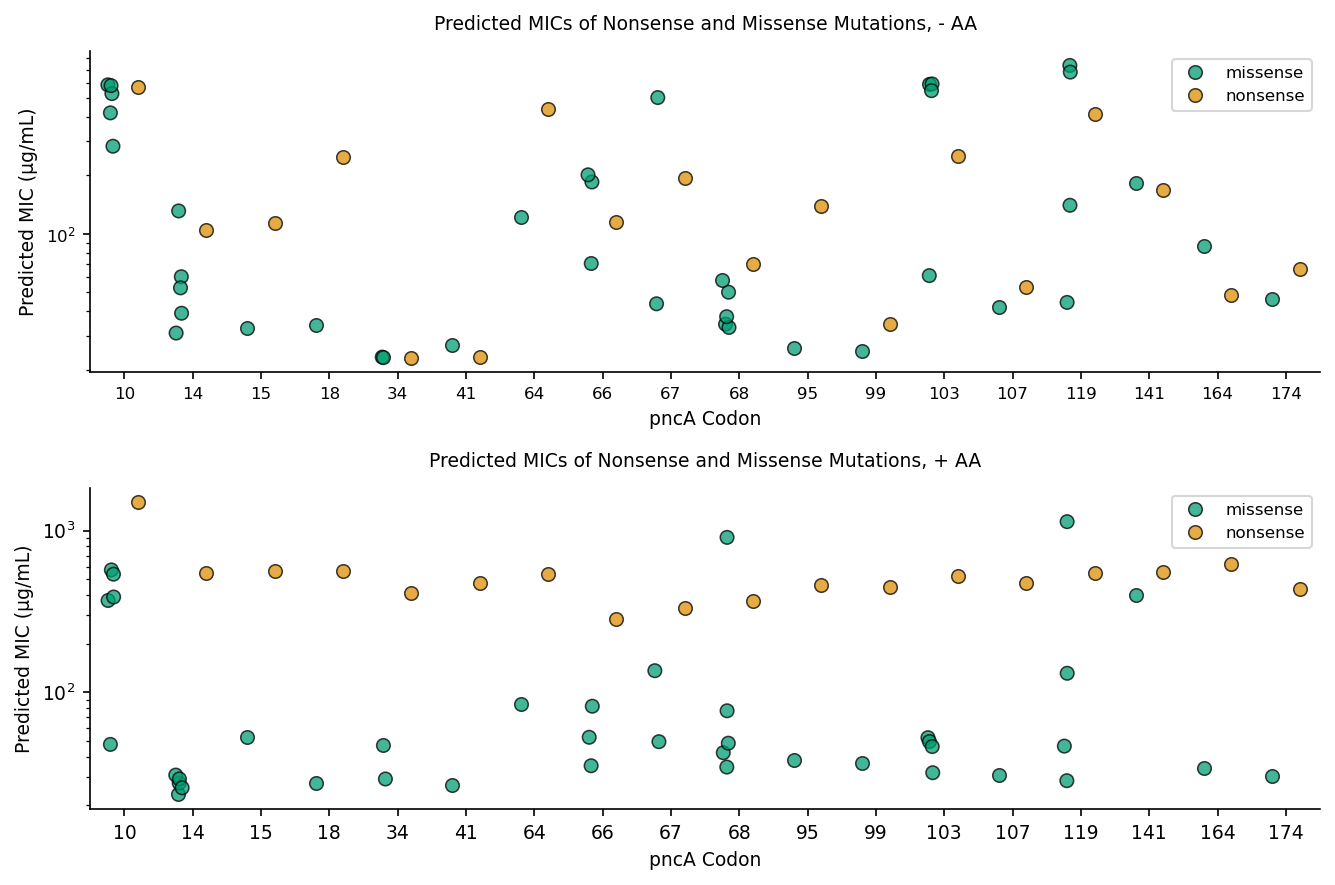

In [10]:
model_path_1 = "PZA"
model_path_2 = 'PZA_amino_acid'
locus = 'pncA'
gene = 'pncA'

compare_missense_nonsense_predictions_two_models(model_path_1, model_path_2, locus, model_name_1='- AA', model_name_2='+ AA', figsize=(6.4, 5.8), V1=False, saveName=f"results/{abbr_drug_dict[model_path_1.split('_')[0]]}/nonsense_missense_comparison.svg")

In [79]:
def which_nonsense_muts_present_in_training_data(df_phenos, df_nonsense, gene):
    '''
    Get a boolean variable for whether each variant is present in the training dataset
    '''
    
    df_nonsense['variant'] = df_nonsense['ROLLINGDB_ID'].str.replace('_p_', '_p.').str.replace('+', '*')
    df_train = df_phenos.query("category=='train_set'")

    if '-' in gene:
        gene = gene.split('-')[0]

    nonsense_muts_df = isolate_variants.query("ROLLINGDB_ID in @df_train.ROLLINGDB_ID & GENE==@gene").merge(df_nonsense[['variant']].drop_duplicates(), on='variant')

    isolates_with_nonsense_muts = nonsense_muts_df.ROLLINGDB_ID.unique()
    
    print(f"{len(isolates_with_nonsense_muts)} training isolates have early stop codons in {gene}")

    df_nonsense['train_nonsense'] = df_nonsense['variant'].isin(nonsense_muts_df.variant.values).astype(int)
    return df_nonsense
    
    

def which_missense_muts_present_in_training_data(df_phenos, df_nonsense, gene):
    '''
    Get a boolean variable for whether each variant is present in the training dataset
    '''
    
    df_nonsense['variant'] = df_nonsense['ROLLINGDB_ID'].str.replace('_p_', '_p.').str.replace('+', '*')
    df_train = df_phenos.query("category=='train_set'")

    if '-' in gene:
        gene = gene.split('-')[0]

    sense = h37Rv_full.query("Name==@gene")['Strand'].values[0]

    nonsyn_muts_df = isolate_variants.query("ROLLINGDB_ID in @df_train.ROLLINGDB_ID & GENE==@gene & variant.str.contains('_p.')").reset_index(drop=True)

    # add codon
    nonsyn_muts_df['codon'] = nonsyn_muts_df['variant'].apply(get_variant_number, args=sense).astype(int)
    
    df_nonsense['train_nonsilent'] = df_nonsense['codon'].isin(nonsyn_muts_df['codon']).astype(int)

    return df_nonsense


    
def plot_nonsense_predictions(model_path, locus, figsize=(12, 7), saveName=None):

    drug = model_path.split('_')[0]
    cc = cc_dict[drug]
    gene = locus.split('-')[0]
    
    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", locus, "test_predictions.csv"))
    ssm_predictions = ssm_predictions.query("ROLLINGDB_ID.str.contains('\+') | ROLLINGDB_ID == 'MT_H37Rv'")

    # get the codon
    for i, row in ssm_predictions.iterrows():
        if row['ROLLINGDB_ID'] != 'MT_H37Rv':
            ssm_predictions.loc[i, 'codon'] = int(row['ROLLINGDB_ID'].split('_')[-1].replace('+', '')[3:])

    plot_df = ssm_predictions.query("ROLLINGDB_ID != 'MT_H37Rv'")
    plot_df['codon'] = plot_df['codon'].astype(int)

    # add annotation for whether or not each variant is in the training dataset
    df_phenos = pd.read_csv(os.path.join(data_dir, drug, 'data_for_model.csv'))
    plot_df = which_nonsense_muts_present_in_training_data(df_phenos, plot_df, locus)
    # plot_df = which_missense_muts_present_in_training_data(df_phenos, plot_df, locus)

    hue_col = 'train_nonsense'
    plot_df[hue_col] = plot_df[hue_col].map({0: 'Train Absent', 1: 'Train Present'})
    color_palette = dict(zip(['Train Absent', 'Train Present'], sns.color_palette('colorblind').as_hex()))
    size_dict = {'Train Absent': 15, 'Train Present': 25}

    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
        
    sns.scatterplot(data=plot_df,
                      x='codon',
                      y='pred_MIC',
                      hue=hue_col,
                      palette=color_palette,
                      # palette=dict(zip([model_name_1, model_name_2], sns.color_palette('colorblind').as_hex())),
                      alpha=0.9,
                      # style='train',
                      size=hue_col,
                      sizes=size_dict,
                      edgecolor='black',
                      linewidth=0.75,
                      ax=ax,
                      zorder=2,
                      legend=True
                     )
    
    # # connect predictions at the same amino acid site
    # plt.vlines(x=plot_df.query("variable==@model_name_1")['codon'].values,
    #            ymin=plot_df.query("variable==@model_name_1")['value'].values, 
    #            ymax=plot_df.query("variable==@model_name_2")['value'].values, 
    #            color='darkgray',
    #            linewidth=1,
    #            zorder=1,
    #            label=''
    #           )

    h37Rv_predictions = ssm_predictions.query("ROLLINGDB_ID == 'MT_H37Rv'")['pred_MIC'].values[0]
    
    if drug == 'PZA':
        ax.set_yscale('log', base=10)
    else:
        ax.set_yscale('log', base=2)
        
    ax.axhline(y=h37Rv_predictions, color='black', linewidth=0.75, linestyle='--', zorder=0, label=f'H37Rv = {np.round(h37Rv_predictions, 1)} µg/mL')
    ax.axhline(y=cc, color='darkred', linewidth=0.75, linestyle='--', zorder=0, label=f'CC = {cc} µg/mL')
    ax.legend(ncol=1, loc='best', fontsize=8)# loc='upper right', bbox_to_anchor=(0.5, -0.1))
    
    ax.set_xlabel(f"{gene} Residue (L = {plot_df.codon.max()})", fontsize=10)
    ax.set_ylabel('Predicted MIC (µg/mL)', fontsize=10)
    
    # ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize=9)
    # ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=9)
    
    ax.set_xlim(left=0, right=int(plot_df.codon.max()*1.01))
    ax.set_title(f"Predicted MICs for Nonsense mutations in {locus.split('-')[0]}")
    
    plt.tight_layout()
    sns.despine()

    if saveName is not None:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
            
        plt.savefig(saveName, bbox_inches='tight')
    else:
        plt.show()

    return plot_df

161 training isolates have early stop codons in ethA


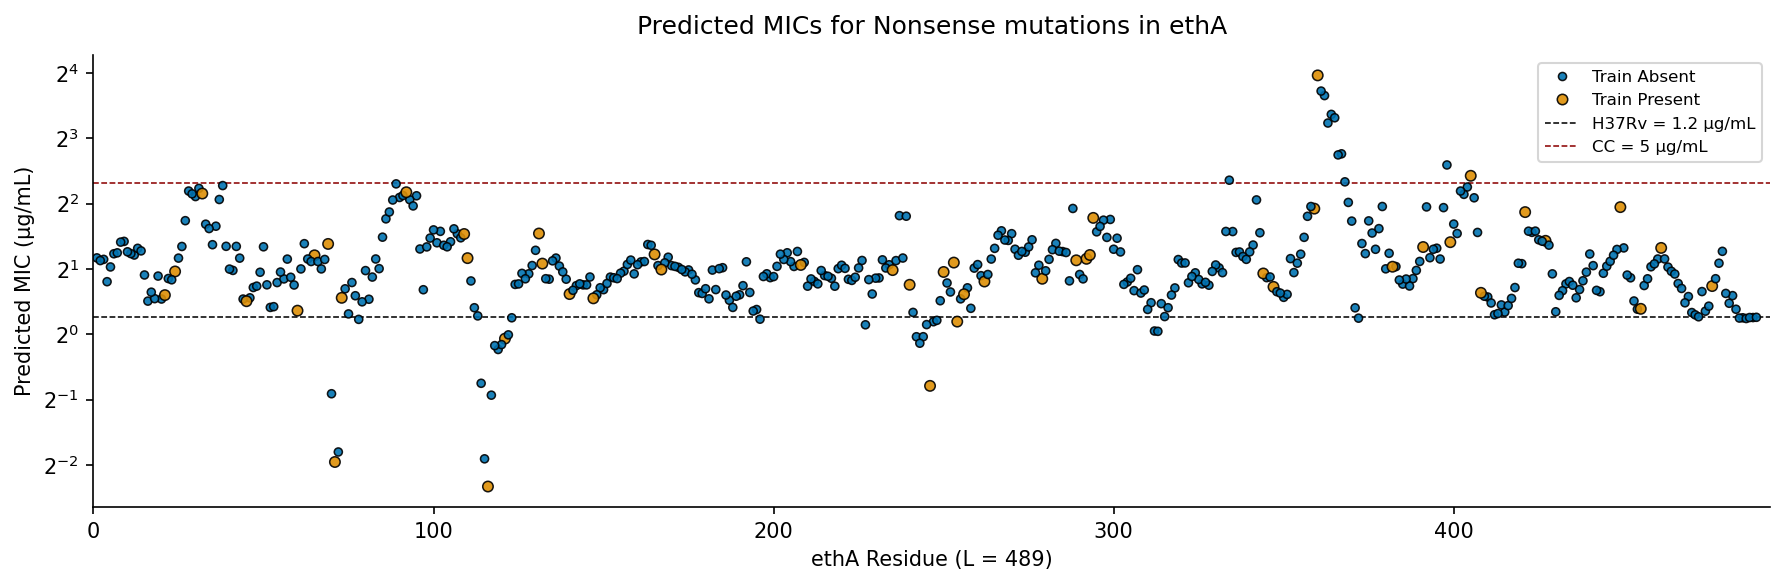

In [132]:
model_path = "ETH_lineage_amino_acid"
locus = 'ethA'

df_ETH_ethA = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense_lineage_AA.svg")

In [81]:
len(df_ETH_ethA.query("pred_MIC > 5")), len(df_ETH_ethA), (len(df_ETH_ethA)-len(df_ETH_ethA.query("pred_MIC > 5")))/len(df_ETH_ethA)

(12, 489, 0.9754601226993865)

In [82]:
st.spearmanr(df_ETH_ethA['codon'], df_ETH_ethA['pred_MIC'])

SignificanceResult(statistic=-0.04086035299164422, pvalue=0.3672570610568363)

1 training isolates have early stop codons in mshA


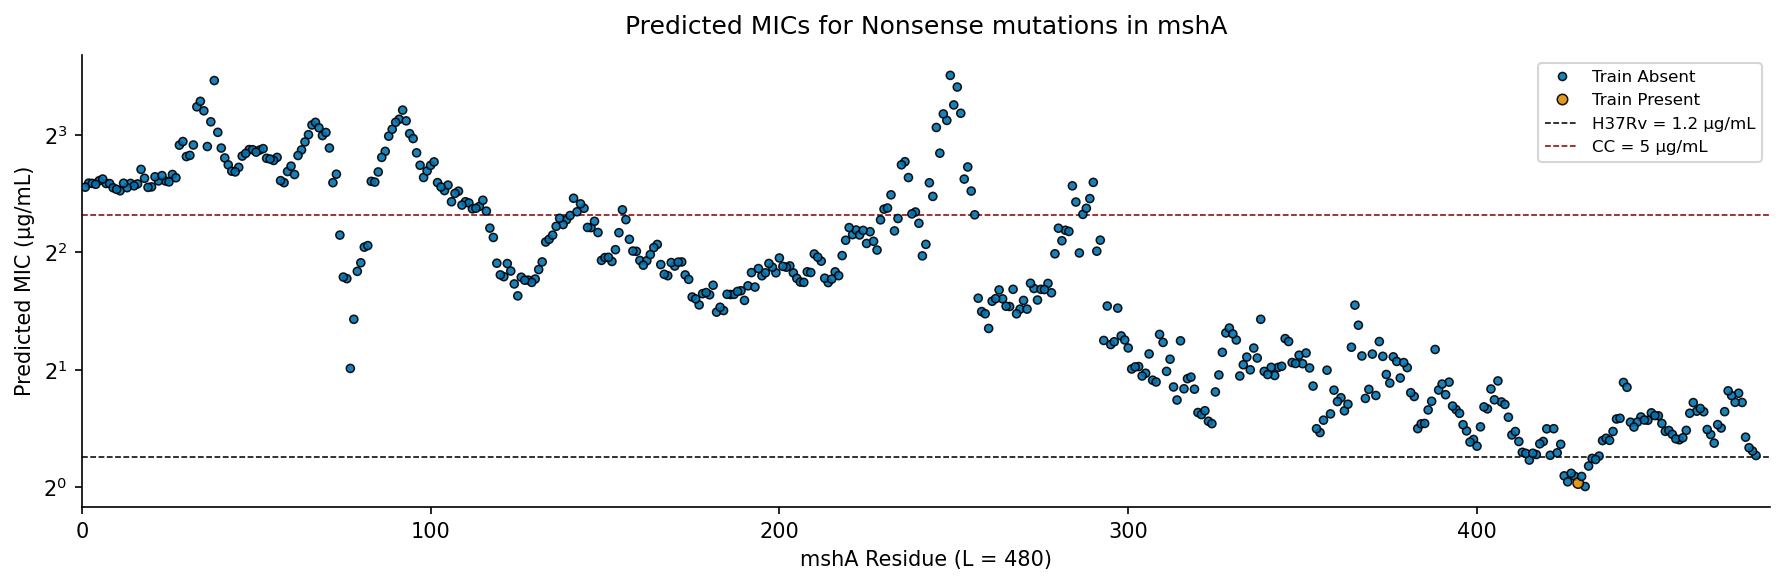

In [84]:
model_path = "ETH_lineage_amino_acid"
locus = 'mshA'

df_ETH_mshA = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense_lineage_AA.svg")

In [85]:
st.spearmanr(df_ETH_mshA['codon'], df_ETH_mshA['pred_MIC'])

SignificanceResult(statistic=-0.8769451039284024, pvalue=3.216009118379783e-154)

17 training isolates have early stop codons in katG


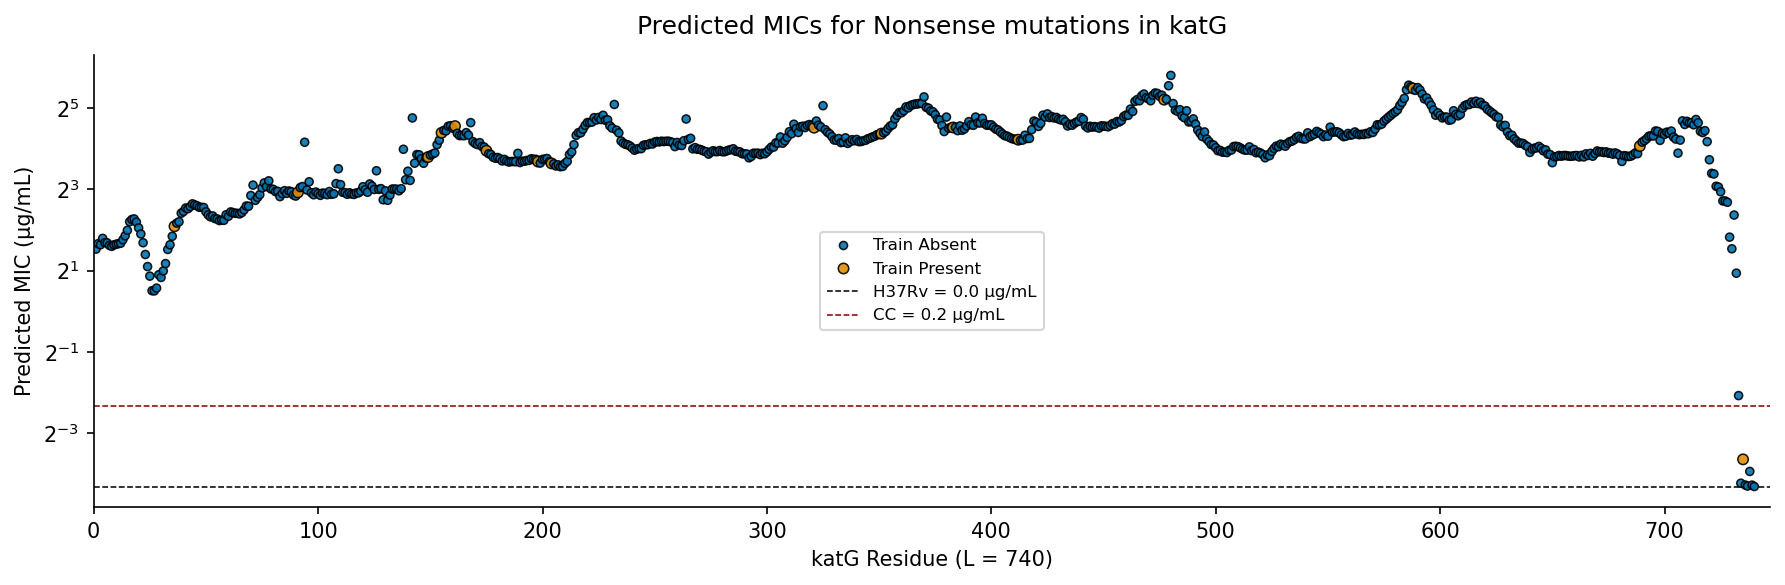

In [92]:
model_path = "INH_lineage_amino_acid"
locus = 'katG-furA'
gene = 'katG'

df_INH_katG = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{gene}_nonsense_lineage_AA.svg")

In [93]:
df_INH_katG.query("pred_MIC <= 0.2").sort_values("codon")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
14668,katG_p_Leu734+,-4.235435,0.053089,734,katG_p.Leu734*,Train Absent
14688,katG_p_Asp735+,-3.647736,0.079785,735,katG_p.Asp735*,Train Present
14708,katG_p_Arg736+,-4.280860,0.051444,736,katG_p.Arg736*,Train Absent
14728,katG_p_Phe737+,-4.304764,0.050598,737,katG_p.Phe737*,Train Absent
14748,katG_p_Asp738+,-3.945068,0.064926,738,katG_p.Asp738*,Train Absent
14769,katG_p_Val739+,-4.282197,0.051396,739,katG_p.Val739*,Train Absent
14788,katG_p_Arg740+,-4.316831,0.050177,740,katG_p.Arg740*,Train Absent


15 training isolates have early stop codons in pncA


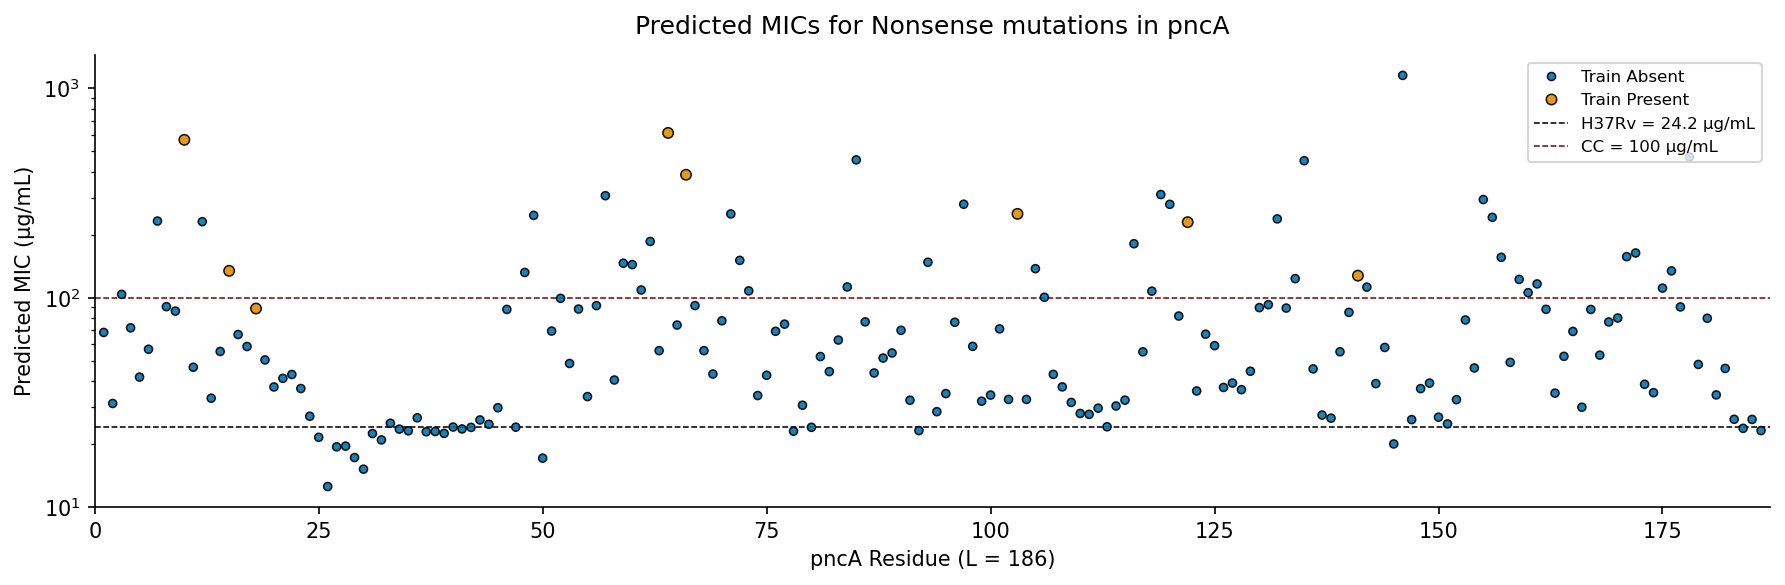

In [12]:
model_path = "PZA"
locus = 'pncA'

df_PZA_pncA = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense.svg")

15 training isolates have early stop codons in pncA


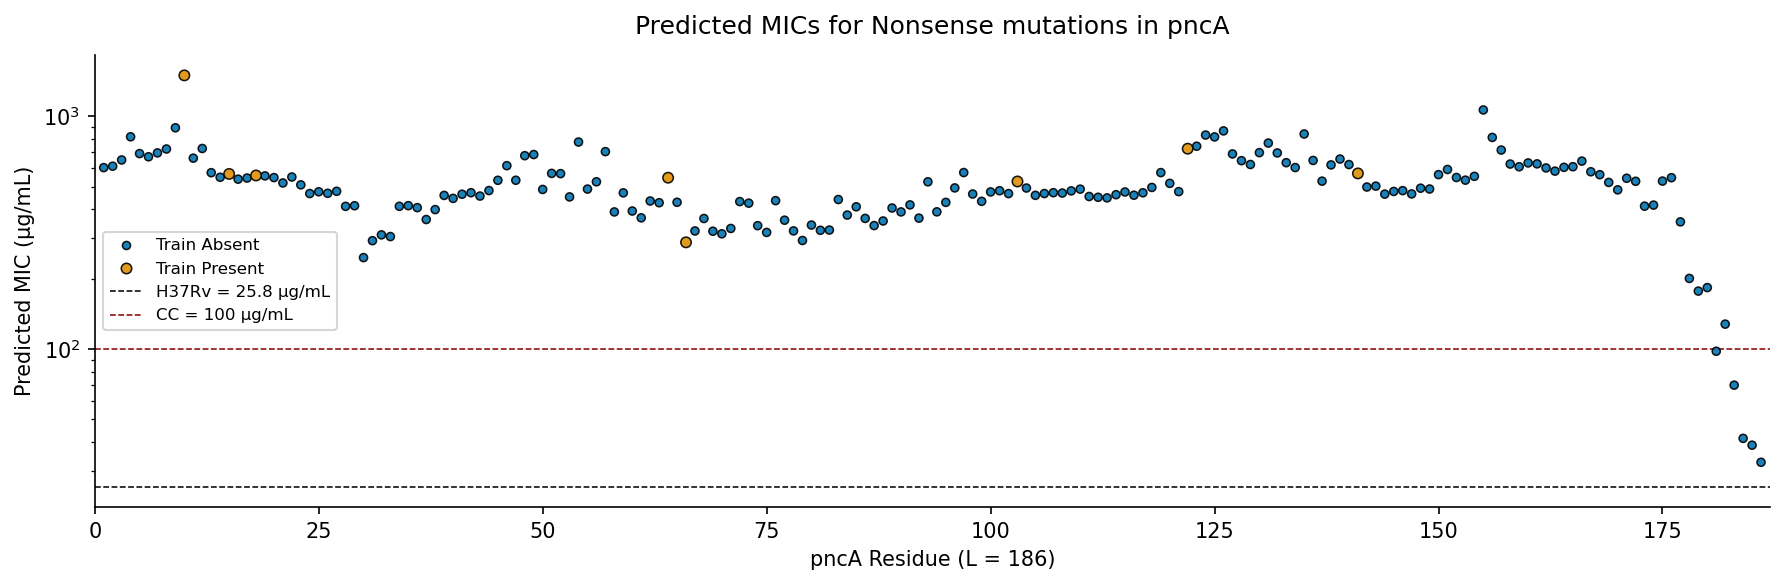

In [88]:
model_path = "PZA_amino_acid"
locus = 'pncA'

df_PZA_pncA_AA = plot_nonsense_predictions(model_path, locus=locus, saveName=f"results/{abbr_drug_dict[model_path.split('_')[0]]}/{locus}_nonsense_AA.svg")

In [89]:
st.spearmanr(df_PZA_pncA_AA['codon'], df_PZA_pncA_AA['pred_MIC'])

SignificanceResult(statistic=0.0025260036645235883, pvalue=0.9727033829010077)

In [24]:
num_pred_R = len(df_PZA_pncA.query('pred_MIC > 100'))
num_total = len(df_PZA_pncA)

print(f"{num_pred_R}/{num_total} ({np.round(num_pred_R/num_total, 2)*100})% pncA mutations predicted to cause R")

46/186 (25.0)% pncA mutations predicted to cause R


In [25]:
num_pred_R = len(df_PZA_pncA_AA.query('pred_MIC > 100'))
num_total = len(df_PZA_pncA_AA)

print(f"{num_pred_R}/{num_total} ({np.round(num_pred_R/num_total, 2)*100})% pncA mutations predicted to cause R")

181/186 (97.0)% pncA mutations predicted to cause R


In [30]:
df_PZA_pncA_AA.query("pred_MIC <= 100").sort_values("codon")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
1340,pncA_p_Glu181+,6.616730,98.137310,181,pncA_p.Glu181*,Train Absent
3560,pncA_p_Val183+,6.133023,70.181690,183,pncA_p.Val183*,Train Absent
1100,pncA_p_Cys184+,5.374344,41.480010,184,pncA_p.Cys184*,Train Absent
2661,pncA_p_Ser185+,5.276850,38.769500,185,pncA_p.Ser185*,Train Absent
2681,pncA_p_Ser186+,5.033194,32.744804,186,pncA_p.Ser186*,Train Absent


In [15]:
df_PZA_pncA_AA.query("codon==182")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
2140,pncA_p_Leu182+,7.003441,128.3057,182,pncA_p.Leu182*,Train Absent


In [14]:
df_PZA_pncA_AA.query("pred_MIC <= 100").sort_values("codon")

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,variant,train_nonsense
1340,pncA_p_Glu181+,6.616730,98.137310,181,pncA_p.Glu181*,Train Absent
3560,pncA_p_Val183+,6.133023,70.181690,183,pncA_p.Val183*,Train Absent
1100,pncA_p_Cys184+,5.374344,41.480010,184,pncA_p.Cys184*,Train Absent
2661,pncA_p_Ser185+,5.276850,38.769500,185,pncA_p.Ser185*,Train Absent
2681,pncA_p_Ser186+,5.033194,32.744804,186,pncA_p.Ser186*,Train Absent


In [23]:
df_PZA_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [22]:
isolate_variants.query("variant=='pncA_p.Ser66*'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V2,confidence_V2,drug_V1,confidence_V1
171704,SAMN05915262,2289045,G,T,PASS,5066.0,False,0.99,147.0,36.0,60.0,stop_gained,pncA,c.197C>A,p.Ser66*,pncA_p.Ser66*,Pyrazinamide,2) Assoc w R - Interim,NaN,NaN


In [24]:
df_PZA_phenos.query("ROLLINGDB_ID=='SAMN05915262'")

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category
135,SAMN05915262,farhat_internal,MGIT,MGIT,200.0,250.0,300.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.003634,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,4,0,1.0,4-1,train_set


# 2.3: Did the models predict resistance for Group 1 Mutations?

In [32]:
def did_model_get_missense_WHO_Rassoc_mutations(model_path, gene):

    drug = model_path.split("_")[0]
    cc = cc_dict[drug]
    
    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", gene, "test_predictions.csv")).query("~ROLLINGDB_ID.str.contains('\+') & ROLLINGDB_ID != 'MT_H37Rv'").reset_index(drop=True)

    # add codon
    for i, row in ssm_predictions.iterrows():
        ssm_predictions.loc[i, 'codon'] = int(row['ROLLINGDB_ID'].split('_')[-1][3:-3])

    # rename to original format to merge with WHO catalog
    ssm_predictions['ROLLINGDB_ID'] = ssm_predictions['ROLLINGDB_ID'].str.replace('_p_', '_p.')
    ssm_predictions['drug'] = abbr_drug_dict[drug]
    
    # keep only those in the catalog
    ssm_predictions = ssm_predictions.merge(who_variants_V2[['drug', 'variant', 'FINAL CONFIDENCE GRADING']], left_on=['drug', 'ROLLINGDB_ID'], right_on=['drug', 'variant'], how='inner')
    
    ssm_predictions = ssm_predictions.loc[ssm_predictions['FINAL CONFIDENCE GRADING'].isin(['1) Assoc w R'])]

    found = len(ssm_predictions.query("pred_MIC > @cc"))
    missed = len(ssm_predictions.query("pred_MIC <= @cc"))
    
    print(f"Predicted resistance for {found}/{found + missed} ({np.round(found / (found + missed)*100, 2)}%) of Group 1 missense mutations")

    return ssm_predictions

In [28]:
drug = 'PZA'

# _ = did_model_get_missense_WHO_Rassoc_mutations(drug, 'pncA')
_ = did_model_get_missense_WHO_Rassoc_mutations(f"{drug}_amino_acid", 'pncA')

Predicted resistance for 51/110 (46.36%) of Group 1 missense mutations


In [13]:
drug = 'INH'

katG_AA_missense = did_model_get_missense_WHO_Rassoc_mutations(f"{drug}_lineage_amino_acid", 'katG-furA')

Predicted resistance for 3/4 (75.0%) of Group 1 missense mutations


In [14]:
katG_AA_missense

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,codon,drug,variant,FINAL CONFIDENCE GRADING
375,katG_p.Ser315Arg,1.841795,3.584557,315.0,Isoniazid,katG_p.Ser315Arg,1) Assoc w R
376,katG_p.Ser315Asn,1.660991,3.162336,315.0,Isoniazid,katG_p.Ser315Asn,1) Assoc w R
378,katG_p.Ser315Thr,1.767588,3.404842,315.0,Isoniazid,katG_p.Ser315Thr,1) Assoc w R
397,katG_p.Trp328Leu,-4.270638,0.051810,328.0,Isoniazid,katG_p.Trp328Leu,1) Assoc w R


In [33]:
def combine_site_saturation_mutagenesis_results(model_path, locus, gene):

    if 'mmp' in locus:
        ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", 'mmpLS5', "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'mutation'})
        ssm_predictions = ssm_predictions.query("mutation.str.startswith(@locus) | mutation == 'MT_H37Rv'")
    else:
        ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", locus, "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'mutation'})
    
    # add amino acid codon
    for i, row in ssm_predictions.iterrows():
        if '+' in row['mutation']:
            ssm_predictions.loc[i, 'codon'] = int(row['mutation'].split('_')[-1].replace('+', '')[3:])
        elif row['mutation'] != 'MT_H37Rv':
            ssm_predictions.loc[i, 'codon'] = int(row['mutation'].split('_')[-1][3:-3])
        else:
            ssm_predictions.loc[i, 'codon'] = 0

    # add binary value for the predicted MICs
    ssm_predictions['pred_phenotype'] = (ssm_predictions['pred_MIC'] > 100).fillna(0).astype(int)
    
    # for plotting
    ssm_predictions['mut_AA'] = ssm_predictions['mutation'].str[-3:]
    
    # get MIC fold change to plot diverging heatmap
    h37Rv_pred = ssm_predictions.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0]
    ssm_predictions['log_fold_change_H37Rv'] = np.log(ssm_predictions['pred_MIC'] / h37Rv_pred)

    # no nonsense plotted in this graph
    missense_pred_matrix = ssm_predictions.query("~mutation.str.contains('\+') & mutation != 'MT_H37Rv'")

    # keep only first codon changes that are alternative start codons. The amino acid is not changed in these, just 
    missense_pred_matrix = missense_pred_matrix.loc[~((missense_pred_matrix['codon']==1) & (~missense_pred_matrix['mutation'].str.contains('|'.join(['1Val', '1Leu', '1Ile', '1Met']))))]

    # PLOT LOG FOLD CHANGE RELATIVE TO H37RV
    missense_pred_matrix = missense_pred_matrix.pivot(index='codon', columns='mut_AA', values='log_fold_change_H37Rv')
    
    missense_pred_matrix.index = missense_pred_matrix.index.values.astype(int)
    
    # check that the NaNs are the reference amino acids. Not true for the first codon because all the non-Met/Val/Ile/Leu cases will be NaN
    assert len(np.unique(missense_pred_matrix.iloc[1:].isna().sum(axis=1))) == 1
    assert np.unique(missense_pred_matrix.isna().sum(axis=1))[0] == 1
    
    gene_start, gene_end, gene_sense = h37Rv_genes.query("Symbol==@gene")[['Start', 'End', 'Strand']].values[0]
    
    if gene_sense == '-':
        protein_seq = h37Rv_seq.seq[gene_start-1:gene_end].reverse_complement().translate()
    else:
        protein_seq = h37Rv_seq.seq[gene_start-1:gene_end].translate()
    
    # protein sequence checks. When creating df_protein_seqs for the encoding, alternative start codons were translated to M
    assert protein_seq[0] in ['M', 'V', 'I', 'L']
    assert protein_seq[-1] == '*'
    assert list(str(protein_seq)).index('*') == len(protein_seq) - 1
    
    protein_seq = str(protein_seq)[:-1]
    
    for i, row in missense_pred_matrix.iterrows():

        # first row is loc 1 (because codon 1), not 0 like default
        if i > 1:
            nan_aa = row[row.isna()].index.tolist()
            assert len(nan_aa) == 1
            assert nan_aa[0] == Bio.SeqUtils.IUPACData.protein_letters_1to3[protein_seq[i-1]]
        
    # fill NaNs (no AA change) with a log fold change of 0 (fold change of 1) because sns.clustermap can't handle them
    missense_pred_matrix = missense_pred_matrix.fillna(0)
    
    return ssm_predictions, missense_pred_matrix

In [86]:
def plot_saturation_mutagenesis_heatmap(missense_pred_matrix, locus, gene, x_max=None, col_colors=None, saveName=None):
        
    hydrophobic = 'lightgreen'
    # positive = 'darkred'
    # negative = 'cornflowerblue'
    charged = 'cornflowerblue'
    polar_uncharged = 'mediumpurple'
    other = 'white'
    aromatic = 'orange'
    
    amino_acid_property_colors = pd.DataFrame(index=np.sort(pd.Series(missense_pred_matrix.columns).apply(lambda x: Bio.SeqUtils.IUPACData.protein_letters_3to1[x]).values))
    
    amino_acid_property_colors['color'] = [hydrophobic, other, charged, charged, aromatic, other, charged, hydrophobic, charged, hydrophobic, hydrophobic, polar_uncharged, other, polar_uncharged, charged, polar_uncharged, polar_uncharged, hydrophobic, aromatic, aromatic]
    
    amino_acid_property_colors = amino_acid_property_colors.reset_index()
    amino_acid_property_colors.index = [Bio.SeqUtils.IUPACData.protein_letters_1to3[val] for val in amino_acid_property_colors['index']]

    cluster = sns.clustermap(missense_pred_matrix.T,
                       z_score=None,
                       standard_scale=None,
                       row_cluster=True,
                         row_colors=amino_acid_property_colors[['color']],
                             col_colors=col_colors,
                       col_cluster=False,
                       center=0,
                         linewidths=0.1,
                         linecolor='lightgray',
                       cmap=sns.color_palette("coolwarm", as_cmap=True),
                       figsize=(16, 6),
                       dendrogram_ratio=(0.05, 0.05), # dendrogram size,
                   )

    # Move y-axis to the left
    cluster.ax_heatmap.yaxis.set_ticks_position('left')

    # Move x-axis to the top to be with the color legend
    cluster.ax_heatmap.xaxis.set_ticks_position('top')

    # Adjust the y positions of the tick labels
    for label in cluster.ax_heatmap.get_xticklabels():
        label.set_fontsize(9)

        # move the ticks slightly higher too to not interfere with the coloring
        if col_colors is not None:
            label.set_y(label.get_position()[1] + 0.03)

    # Adjust the position of the row dendrogram axes
    row_dendro_ax = cluster.ax_row_dendrogram.get_position()
    cluster.ax_row_dendrogram.set_position([row_dendro_ax.x0, row_dendro_ax.y0, row_dendro_ax.width, row_dendro_ax.height])
    
    # Get the positions of the main heatmap axes
    pos = cluster.ax_heatmap.get_position()
    
    # Define the position for the colorbar axis: vertical and to the right of the plot
    cbar_ax = plt.axes([pos.x1 + 0.015, pos.y0, 0.01, pos.height])
    
    # Create the colorbar
    cbar = plt.colorbar(cluster.ax_heatmap.collections[0], cax=cbar_ax, orientation='vertical')
    
    # Remove the black outline around the color bar
    cbar.outline.set_visible(False)
    
    # Remove the colorbar axes created by sns.clustermap
    plt.delaxes(cluster.cax)
    
    # remove the "colors" name and ticks for both axis colorings
    cluster.ax_row_colors.set_xticks(ticks=[], labels=[])

    if col_colors is not None:
        cluster.ax_col_colors.set_yticks(ticks=[], labels=[])
    
    # Change rotation of x and y ticks
    cluster.ax_heatmap.set_xticklabels(cluster.ax_heatmap.get_xticklabels(), rotation=90)
    cluster.ax_heatmap.set_yticklabels(cluster.ax_heatmap.get_yticklabels(), rotation=0)
    
    cluster.ax_heatmap.set_xlabel(f'{gene} Residue')
    cluster.ax_heatmap.set_ylabel('')

    if x_max is not None:
        cluster.ax_heatmap.set_xlim(left=2, right=x_max)
    
    sns.despine()

    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')

In [92]:
# def predicted_MIC_by_Yadon_enrichment(ssm_predictionsenesis_results, plot_var='pred_MIC', log_scale=10):

#     fig, ax = plt.subplots()
    
#     # exclude start codon because it's confounding and nonsense mutations
#     df = ssm_predictionsenesis_results.query("codon != 1")# & ~mutation.str.contains('\+')")

#     # change encoding for plotting
#     df['phenotype'] = df['phenotype'].map({-1: 'Low', 0: 'Same', 1: 'High'})

#     sns.boxplot(data=df,
#               #hue='phenotype',
#               y=plot_var,
#                 x='phenotype',
#                 order=['Low', 'Same', 'High'],
#              log_scale=log_scale,
#                 #palette=dict(zip(['Low', 'Same', 'High'], sns.color_palette("coolwarm", n_colors=3).as_hex())),
#                 legend=False,
#                 fliersize=0,
#                 fill=False,
#                 width=0.5,
#                 zorder=2,
#                 color='black',
#                 linewidth=0.75,
#              )

#     sns.stripplot(data=df,
#                   hue='phenotype',
#                   y=plot_var,
#                   x='phenotype',
#                   order=['Low', 'Same', 'High'],
#                  log_scale=log_scale,
#                   palette=dict(zip(['Low', 'Same', 'High'], sns.color_palette("coolwarm", n_colors=3).as_hex())),
#                   alpha=0.75,
#                   linewidth=0.5,
#                   edgecolor='black',
#                   zorder=1,
#                   legend=False
#                  )

#     if plot_var == 'pred_MIC':
#         plt.axhline(y=ssm_predictionsenesis_results.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0], color='black', alpha=0.75, linewidth=0.75, linestyle='--', zorder=0, label='H37Rv')
#         plt.axhline(y=100, color='darkred', alpha=0.75, linewidth=0.75, linestyle='--', zorder=0, label='CC = 100 µg/mL')
#         plt.ylabel('Predicted MIC (µg/mL)')

#     elif plot_var == 'fold_change_H37Rv':
#         plt.axhline(y=1, color='black', alpha=0.75, linewidth=0.75, linestyle='--', zorder=0, label='H37Rv')
#         plt.axhline(y=100/ssm_predictionsenesis_results.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0], color='darkred', alpha=0.75, linewidth=0.75, linestyle='--', zorder=0, label='CC = 100 µg/mL')
#         plt.ylabel('Fold Change')

#     plt.legend(fontsize=8)    
#     plt.xlabel('Mutation Enrichment')
#     sns.despine()
#     plt.show()

Arg231, Gly263, Gly319 and Glu324) (Fig. 3C). Each of these amino acids plays an important role in either the substrate binding or the domain interaction (Fig. 3B). The side-chain amines of Arg273. Gly299 is not in the vicinity of the active site, but should be important for the protein stability as the next residue, Gly300, forms the only interdomain hydrogen bond with Gly61 (Fig. 3A). Although not directly seen in the model, Gly356

 Towards the end of C-terminus, a large α-helix spanning Cys409 to Ile445 crosses back to the N-terminal, which is likely to stabilize the overall folding of the protein. Therefore the mutations within this α-helix, such as in mc24937, would detrimentally affect the conformation of MshA leading to its inactivation.

# GeO Clustering

In [94]:
def average_missense_pred_by_residue_save_for_GeO(model_path, saveDir, gene):
    '''
    Doesn't matter which column you use between pred_MIC, log2_pred_MIC, and fold_change_H37Rv because they're all just transformations of each other.
    '''

    ssm_predictions = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis/saturation_mutagenesis", gene, "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'mutation'})
    
    # add amino acid codon
    for i, row in ssm_predictions.iterrows():
        if '+' in row['mutation']:
            ssm_predictions.loc[i, 'codon'] = int(row['mutation'].split('_')[-1].replace('+', '')[3:])
        elif row['mutation'] != 'MT_H37Rv':
            ssm_predictions.loc[i, 'codon'] = int(row['mutation'].split('_')[-1][3:-3])
        else:
            ssm_predictions.loc[i, 'codon'] = 0

    h37Rv_pred = ssm_predictions.query("mutation=='MT_H37Rv'")['pred_MIC'].values[0]
    ssm_predictions['log_fold_change_H37Rv'] = np.log(ssm_predictions['pred_MIC'] / h37Rv_pred)
    
    codon1_mean = ssm_predictions.query("codon == 1 & mutation.str.contains('|'.join(['1Val', '1Leu', '1Ile', '1Met']))")['log_fold_change_H37Rv'].mean()

    # exclude nonsense mutations, this is only for missense, and exclude H37Rv and first codon, which will be added in manually
    df = pd.DataFrame(ssm_predictions.query("codon > 1 & ~mutation.str.contains('\+')").groupby("codon")['log_fold_change_H37Rv'].mean()).reset_index()
    df.loc[-1, :] = [1, codon1_mean]
    df.columns = ['residue', 'average']
    df = df.sort_values('residue')

    if not os.path.isdir(f"spatial_clustering/{saveDir}"):
        os.makedirs(f"spatial_clustering/{saveDir}")

    df.to_csv(f"spatial_clustering/{saveDir}/values_to_cluster.csv", index=False)

In [26]:
average_missense_pred_by_residue_save_for_GeO("PZA_amino_acid", "pncA_SSM_amino_acid", "pncA")

In [126]:
average_missense_pred_by_residue_save_for_GeO("INH_lineage_amino_acid", "katG_SSM_lineage_amino_acid", "katG-furA")

In [78]:
average_missense_pred_by_residue_save_for_GeO("ETH_lineage_amino_acid", "ethA_SSM_lineage_amino_acid", "ethA")

In [87]:
def plot_saturation_heatmap_with_GeO_colors(model_path, locus, gene, pval_thresh=0.05):

    drug = model_path.split('_')[0]

    GeO_scores = pd.read_csv(f"supplement/{gene}_GeO_scores.csv")[['residue', 'BH_pval', 'G_score']]
    col_colors = GeO_scores.copy().rename(columns={'residue': 'codon'})

    print(f"{len(col_colors.query('BH_pval <= @pval_thresh'))} residues have significant clustering scores at FDR = {pval_thresh}")
        
    col_colors.loc[(col_colors['BH_pval'] <= pval_thresh) & (col_colors['G_score'] > 1), 'color'] = sns.color_palette("coolwarm", n_colors=5).as_hex()[-1] # red
    col_colors.loc[(col_colors['BH_pval'] <= pval_thresh) & (col_colors['G_score'] < 1), 'color'] = sns.color_palette("coolwarm", n_colors=5).as_hex()[0] # blue
    col_colors.loc[(col_colors['BH_pval'] > pval_thresh), 'color'] = '#ffffff' #sns.color_palette("coolwarm", n_colors=5).as_hex()[2]

    protein_length = int((h37Rv_full.query("Name==@gene")['Stop'].values[0] - h37Rv_full.query("Name==@gene")['Start'].values[0] + 1) / 3) - 1
    
    # get the residues that are missing from the structure
    missing_residues = list(set(np.arange(protein_length) + 1) - set(GeO_scores.residue))
    
    # set their color to be insignificant
    col_colors = pd.concat([col_colors, pd.DataFrame({'codon': missing_residues, 'color': '#ffffff'})], axis=0)

    # the structure doesn't have residue 186, so add it
    col_colors = col_colors[['codon', 'color']]
    col_colors = col_colors.set_index('codon')

    # get the AA prediction matrix
    _, AA_matrix = combine_site_saturation_mutagenesis_results(model_path, locus, gene)
    
    plot_saturation_mutagenesis_heatmap(AA_matrix, locus, gene, col_colors=col_colors, saveName=f"results/{abbr_drug_dict[drug]}/{gene}_SSM_heatmap_GeO.svg")

    return AA_matrix

43 residues have significant clustering scores at FDR = 0.05


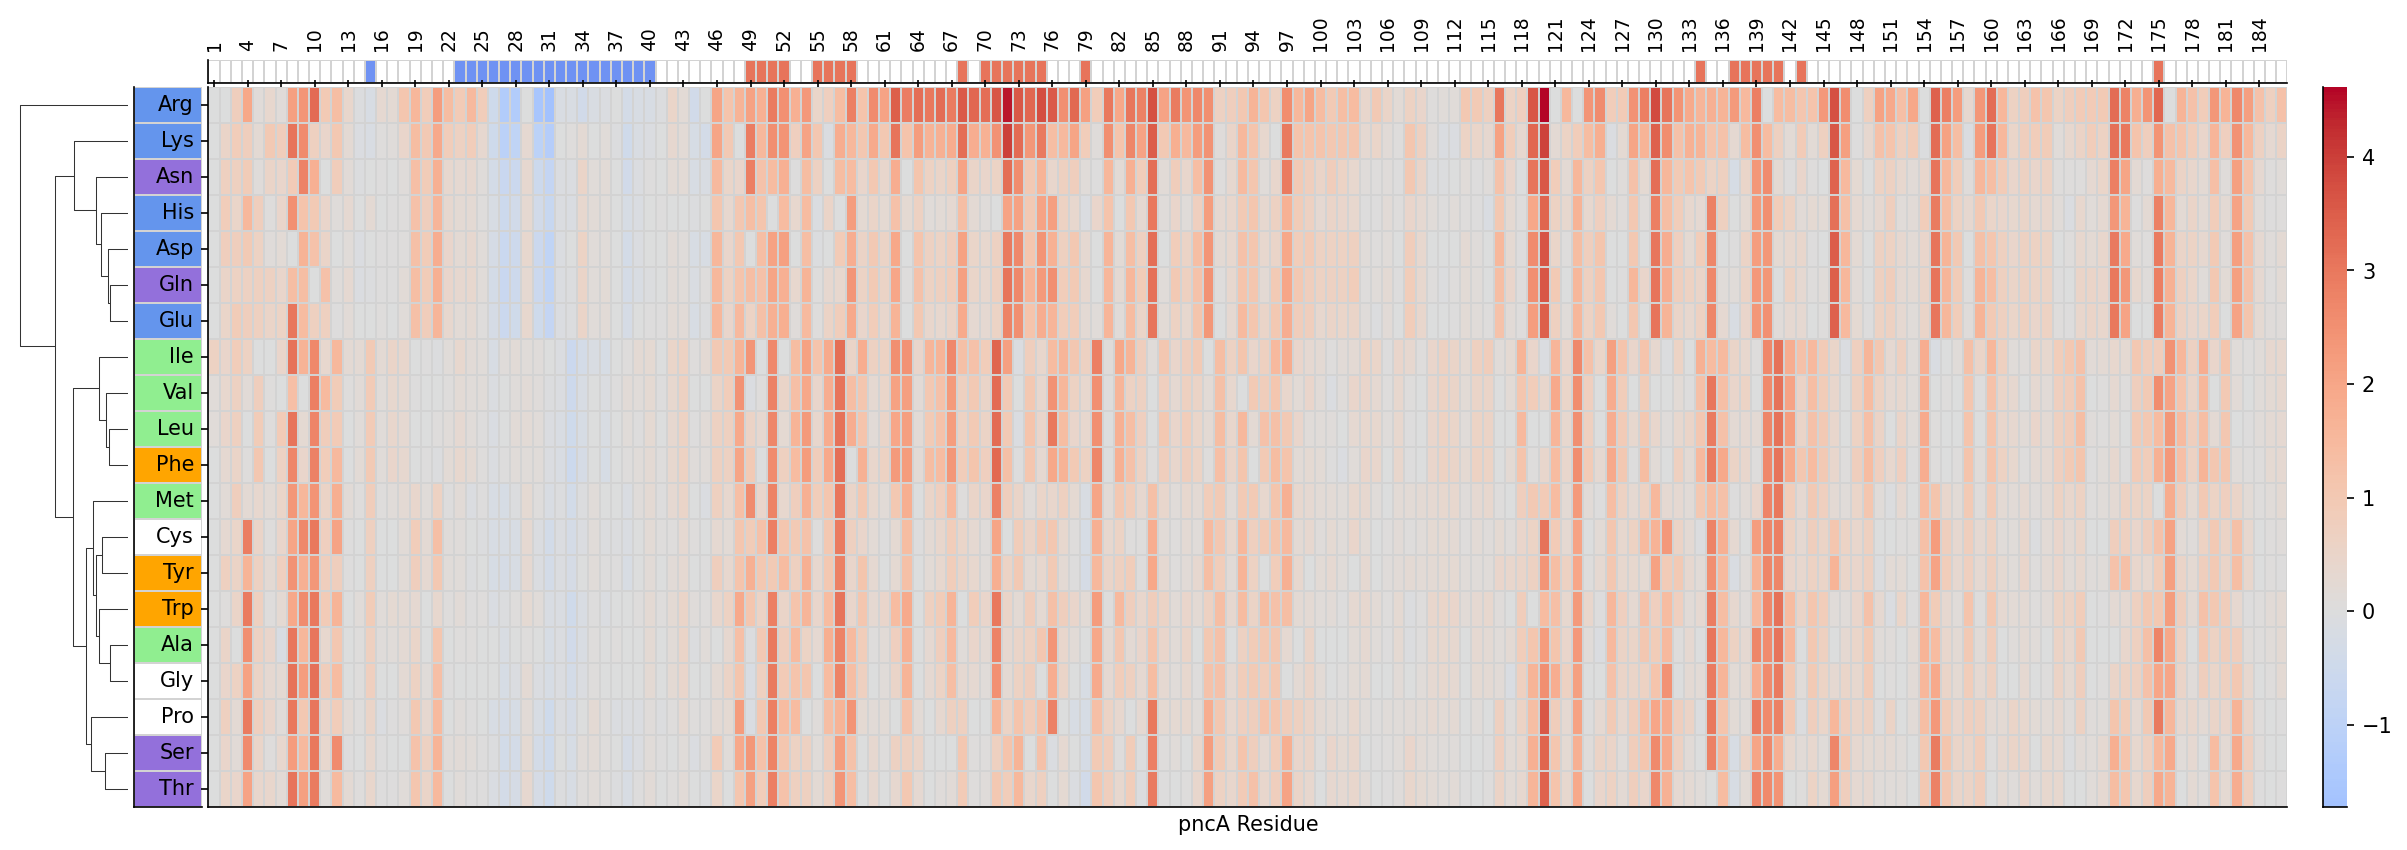

In [36]:
model_path = 'PZA_amino_acid'
locus = 'pncA'
gene = 'pncA'

pncA_missense = plot_saturation_heatmap_with_GeO_colors(model_path, locus, gene)

In [74]:
# F58, W68, P70 -- Phe and Trp are both hydrophobic. Pro might be an electron donor because of the lone pair on N
pd.DataFrame(pncA_missense.loc[[58, 68, 70], :])#.sort_values(68, ascending=False)

mut_AA,Ala,Arg,Asn,Asp,Cys,Gln,Glu,Gly,His,Ile,Leu,Lys,Met,Phe,Pro,Ser,Thr,Trp,Tyr,Val
58,1.459247,2.873553,1.415316,1.806356,0.706448,2.395849,1.920877,1.351519,2.222274,0.532669,1.844071,1.542189,0.534484,0.000000,2.428310,1.206303,1.335111,0.444744,0.443403,1.365315
68,0.159399,3.546014,2.053424,2.108025,0.492606,2.138887,1.880896,0.318007,1.370250,1.295485,0.641747,3.174025,0.048084,0.877573,0.717527,1.068587,0.915263,0.000000,0.531727,0.702199
70,0.213838,3.196928,0.462006,0.365441,0.098894,0.364307,0.285675,0.126851,0.092454,0.848780,0.561526,1.707196,0.457632,0.735279,0.000000,0.082616,0.091309,0.478328,0.140954,0.515107


In [78]:
pos = 58
pd.DataFrame(pncA_missense.loc[pos, :]).sort_values(pos, ascending=False).head()

,58
mut_AA,
Arg,2.873553
Pro,2.428310
Gln,2.395849
His,2.222274
Glu,1.920877


In [79]:
pos = 68
pd.DataFrame(pncA_missense.loc[pos, :]).sort_values(pos, ascending=False).head()

,68
mut_AA,
Arg,3.546014
Lys,3.174025
Gln,2.138887
Asp,2.108025
Asn,2.053424


In [80]:
pos = 70
pd.DataFrame(pncA_missense.loc[pos, :]).sort_values(pos, ascending=False).head()

,70
mut_AA,
Arg,3.196928
Lys,1.707196
Ile,0.848780
Phe,0.735279
Leu,0.561526


71 residues have significant clustering scores at FDR = 0.05


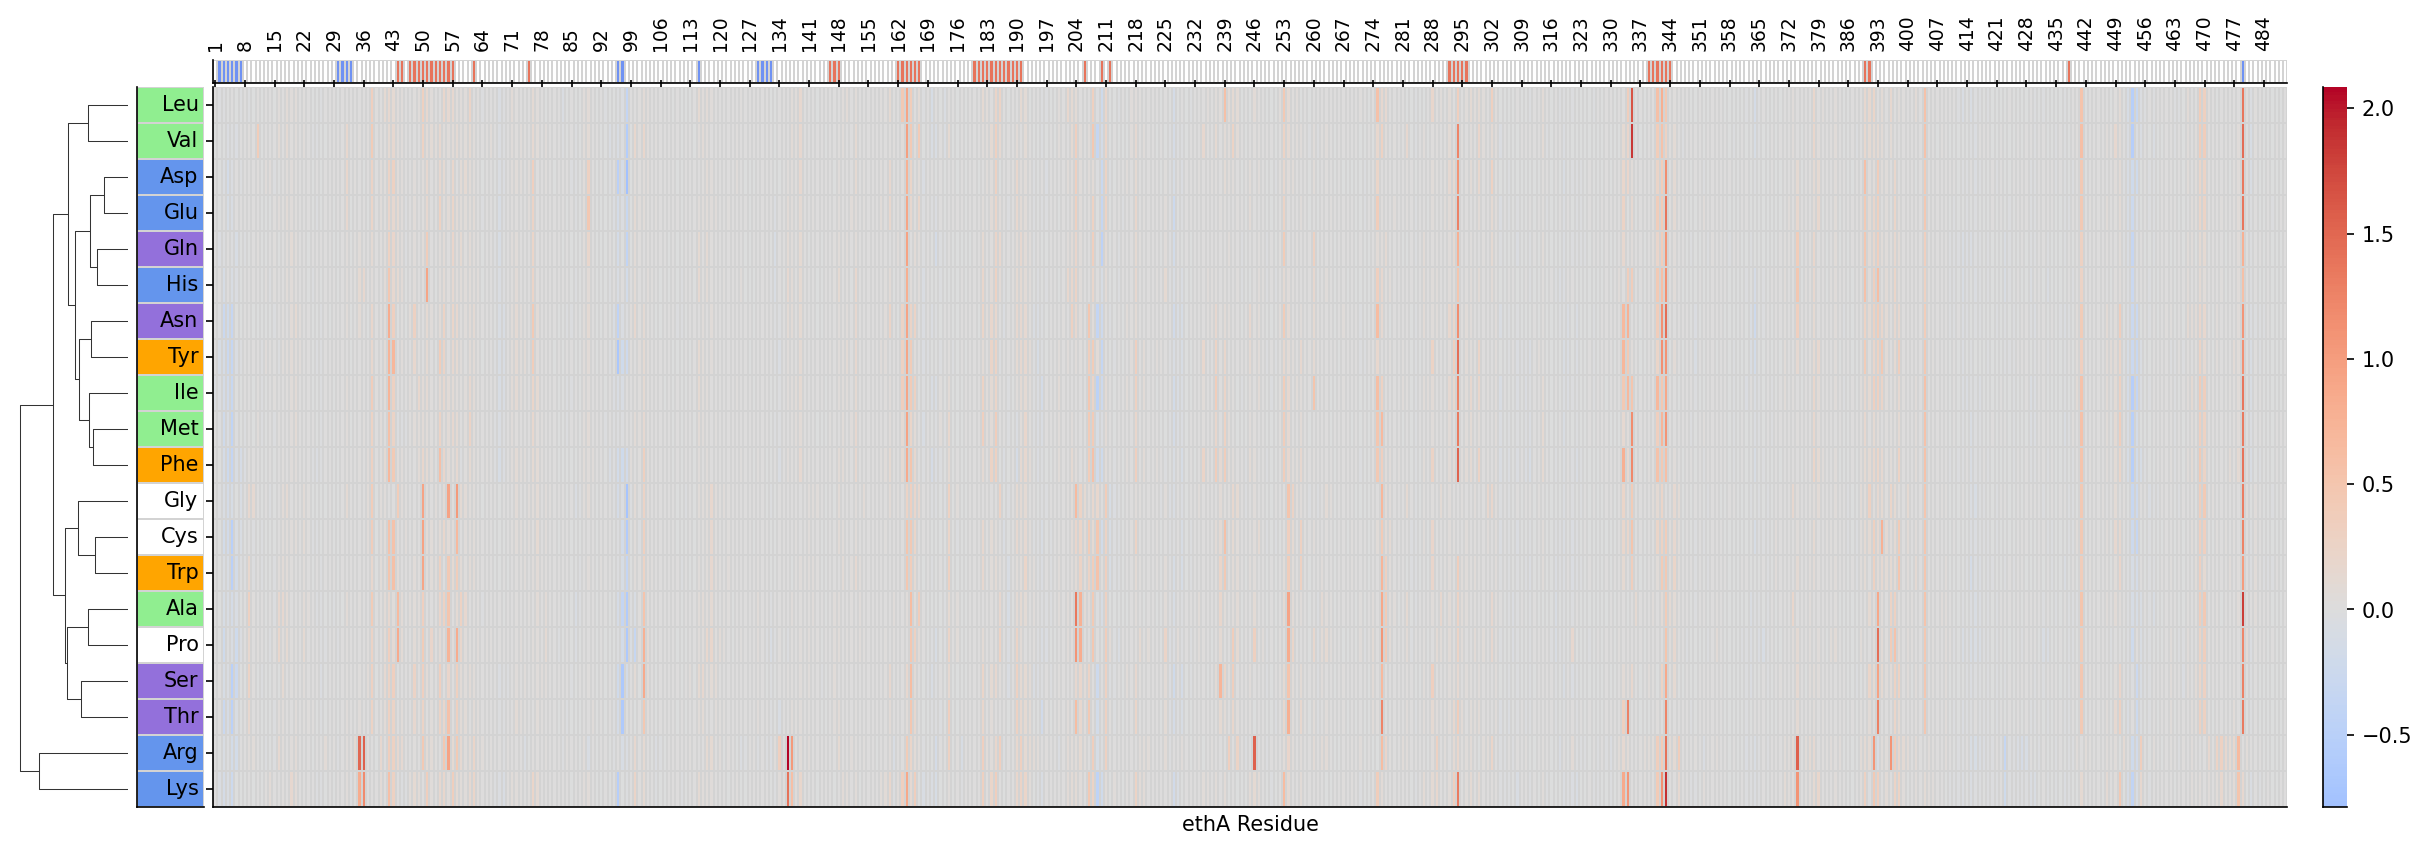

In [88]:
model_path = 'ETH_lineage_amino_acid'
locus = 'ethA'
gene = 'ethA'

ethA_missense = plot_saturation_heatmap_with_GeO_colors(model_path, locus, gene)

In [89]:
for drug in os.listdir(data_dir):

    kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml"))

    for locus in kwargs['tier1_loci']:
        print(f"python3 -u analysis/addl_data_predictions.py -c config_files/config_{drug.lower()}.yaml --insilico-muts --lineage --amino-acid --predict --locus {locus}")

python3 -u analysis/addl_data_predictions.py -c config_files/config_bdq.yaml --insilico-muts --lineage --amino-acid --predict --locus mmpLS5
python3 -u analysis/addl_data_predictions.py -c config_files/config_bdq.yaml --insilico-muts --lineage --amino-acid --predict --locus Rv0678
python3 -u analysis/addl_data_predictions.py -c config_files/config_bdq.yaml --insilico-muts --lineage --amino-acid --predict --locus atpE
python3 -u analysis/addl_data_predictions.py -c config_files/config_bdq.yaml --insilico-muts --lineage --amino-acid --predict --locus pepQ
python3 -u analysis/addl_data_predictions.py -c config_files/config_emb.yaml --insilico-muts --lineage --amino-acid --predict --locus aftA-embCAB
python3 -u analysis/addl_data_predictions.py -c config_files/config_emb.yaml --insilico-muts --lineage --amino-acid --predict --locus aftB-ubiA
python3 -u analysis/addl_data_predictions.py -c config_files/config_eth.yaml --insilico-muts --lineage --amino-acid --predict --locus fabG1-inhA
pytho

In [28]:
ethA_summary = pd.DataFrame(ethA_missense.max(axis=1)).reset_index()
ethA_summary.columns = ['residue', 'mean']
ethA_summary.sort_values("mean", ascending=False).head()

,residue,mean
65,66,3.860436
256,257,3.301822
67,68,2.913096
138,139,2.768312
41,42,2.291832


In [31]:
ethA_summary.sort_values("mean", ascending=True).head()

,residue,mean
412,413,0.0
424,425,0.0
425,426,0.0
414,415,0.0
124,125,0.0


295 residues have significant clustering scores at FDR = 0.05
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 740]


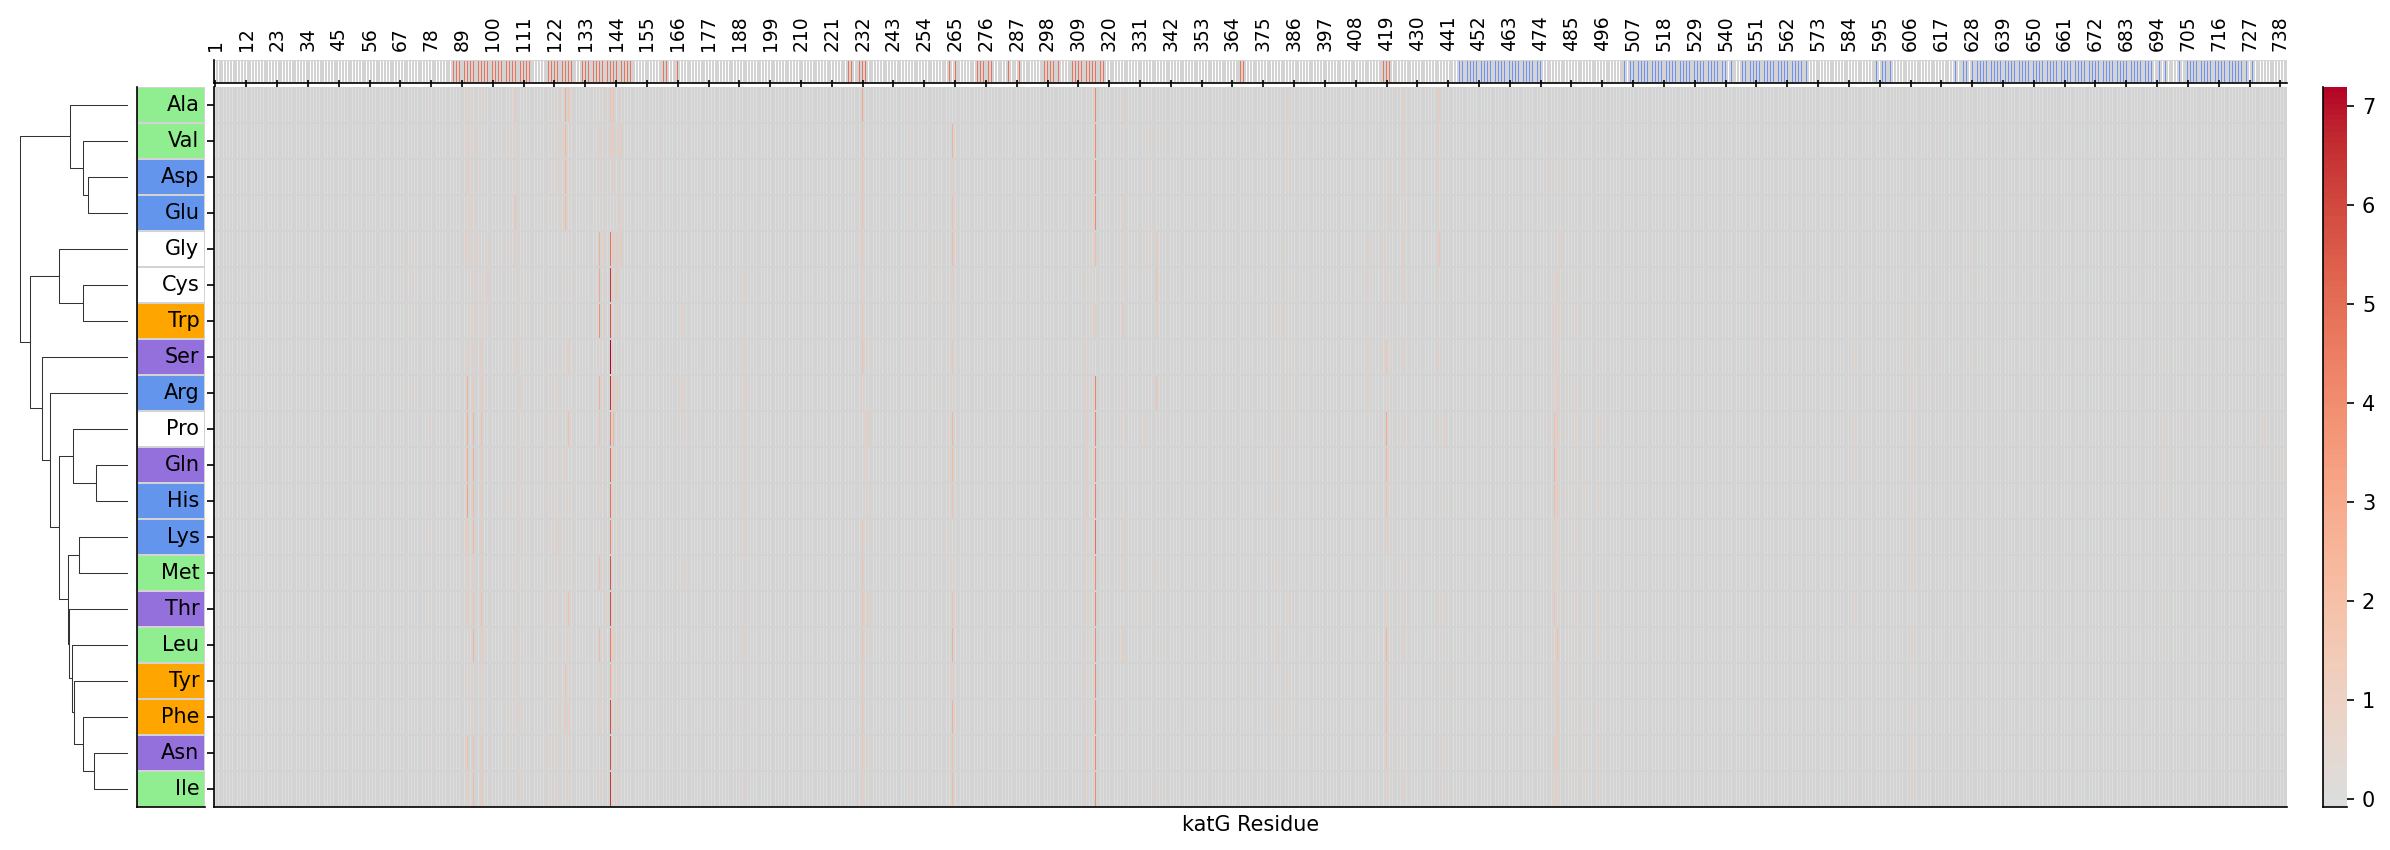

In [93]:
model_path = 'INH_lineage_amino_acid'
locus = 'katG-furA'
gene = 'katG'

katG_missense = plot_saturation_heatmap_with_GeO_colors(model_path, locus, gene)

In [19]:
katG_summary = pd.DataFrame(katG_missense.mean(axis=1)).reset_index()
katG_summary.columns = ['residue', 'mean']
katG_summary.sort_values("mean", ascending=False).head()

,residue,mean
140,142,4.568632
313,315,3.586535
107,109,2.443219
262,264,1.788227
230,232,1.620033


# Hypothesize that the model associates small length changes (not early stop codons) with resistance because it learns the association between nonsense and resistance

## Compute the matched pairs difference in predicted MIC or fold change between for length-changing variants between models with and without AA features

## Restrict to protein length changing variants that are not due to early stop codons. 

In [445]:
# get predictions from models without amino acid features
all_drugs_insilico_pred_noAA = []

for drug in ['RIF', 'INH', 'EMB', 'ETH', 'MXF', 'PZA', 'LEV', 'BDQ']: #os.listdir(data_dir):

    if drug in ['MXF', 'BDQ', 'CFZ', 'DLM', 'ETH']:
        model_path = f"{drug}_lineage"
    else:
        model_path = drug
        
    df = plot_ECDF(model_path, cc_dict[drug], log_base=2, include_uncertain=True, V1=False, saveFig=False, show=False)
    df['gene'] = df['mutation'].str.split('_').str[0]
    df['drug'] = drug

    all_drugs_insilico_pred_noAA.append(df)

all_drugs_insilico_pred_noAA = pd.concat(all_drugs_insilico_pred_noAA)

In [446]:
# keep only protein-coding mutations, drop nonsense mutations
all_drugs_insilico_pred_combined_indels = pd.concat(all_drugs_insilico_pred_combined).query("mutation.str.contains('_p_') & ~mutation.str.contains('\+')").reset_index(drop=True)

all_drugs_insilico_pred_combined = all_drugs_insilico_pred_combined[['drug', 'Locus', 'gene', 'mutation', 'confidence', 'pred_MIC', 'ref_pred', 'fold_change']].rename(columns={'pred_MIC': 'pred_MIC_AA', 'fold_change': 'fold_change_AA'}).merge(all_drugs_insilico_pred_noAA[['drug', 'gene', 'mutation', 'pred_MIC', 'fold_change']], on=['drug', 'gene', 'mutation'])

all_drugs_insilico_pred_combined['pred_MIC_ratio'] = all_drugs_insilico_pred_combined['pred_MIC_AA'] / all_drugs_insilico_pred_combined['pred_MIC']
all_drugs_insilico_pred_combined['log_pred_MIC_ratio'] = np.log(all_drugs_insilico_pred_combined['pred_MIC_ratio'])

In [447]:
# get the affected codon (earliest) for each mutations
for i, row in all_drugs_insilico_pred_combined.iterrows():

    drug = row['drug']
    gene = row['gene']
    locus = row['Locus']
    mutation = row['mutation']
    
    variant = mutation.replace(row['gene'], '')

    # sense doesn't matter here unless return_start_and_end = True
    number = get_variant_number(variant, '+', return_start_and_end=False)

    all_drugs_insilico_pred_combined.loc[i, 'codon'] = number

all_drugs_insilico_pred_combined['codon'] = all_drugs_insilico_pred_combined['codon'].astype(int)

In [454]:
# get protein lengths
length_mapping_dict = {}
ref_length_mapping_dict = {}

for _, row in all_drugs_insilico_pred_combined[['drug', 'Locus']].drop_duplicates().iterrows():

    drug = row['drug']
    locus = row['Locus']
    
    df_protein_seqs = pd.read_csv(os.path.join(results_dir, drug, "inSilico_analysis", locus, "df_protein_seqs.csv"))
    
    for gene in all_drugs_insilico_pred_combined.query("Locus==@locus")['gene'].unique():
        
        df_protein_seqs[f'{gene}_length'] = df_protein_seqs[f'{gene}_AA'].str.replace('-', '').str.len()
        length_mapping_dict.update(dict(zip(df_protein_seqs.query("ROLLINGDB_ID.str.startswith(@gene)")['ROLLINGDB_ID'], df_protein_seqs.query("ROLLINGDB_ID.str.startswith(@gene)")[f'{gene}_length'])))

        ref_length_mapping_dict[gene] = df_protein_seqs.query("ROLLINGDB_ID=='MT_H37Rv'")[f'{gene}_length'].values[0]


all_drugs_insilico_pred_combined['protein_length'] = all_drugs_insilico_pred_combined['mutation'].map(length_mapping_dict)
all_drugs_insilico_pred_combined['ref_protein_length'] = all_drugs_insilico_pred_combined['gene'].map(ref_length_mapping_dict)

assert len(all_drugs_insilico_pred_combined.loc[pd.isnull(all_drugs_insilico_pred_combined['protein_length'])]) == 0

all_drugs_insilico_pred_combined['norm_length'] = all_drugs_insilico_pred_combined['protein_length'] / all_drugs_insilico_pred_combined['ref_protein_length']
all_drugs_insilico_pred_combined['codon_prop'] = all_drugs_insilico_pred_combined['codon'] / all_drugs_insilico_pred_combined['ref_protein_length']

# remove mutations that don't change the length of the protein
all_drugs_insilico_pred_combined = all_drugs_insilico_pred_combined.query("norm_length != 1")
len(all_drugs_insilico_pred_combined)

146

In [455]:
all_drugs_insilico_pred_combined.drug.value_counts()

drug
RIF    37
ETH    31
PZA    31
INH    17
EMB    15
BDQ     9
MXF     3
LEV     3
Name: count, dtype: int64

In [456]:
# this means that there is no relationship between protein length and predicted MIC ratio
st.spearmanr(all_drugs_insilico_pred_combined['norm_length'],
             all_drugs_insilico_pred_combined['pred_MIC_ratio']
            )

SignificanceResult(statistic=-0.05074781118967718, pvalue=0.5429821636743852)

In [457]:
st.spearmanr(all_drugs_insilico_pred_combined['norm_length'],
             all_drugs_insilico_pred_combined['fold_change']
            )

SignificanceResult(statistic=-0.17289409979833406, pvalue=0.036899606847296366)

In [458]:
st.spearmanr(all_drugs_insilico_pred_combined['norm_length'],
             all_drugs_insilico_pred_combined['fold_change_AA']
            )

SignificanceResult(statistic=-0.20853063210284842, pvalue=0.011541579121776991)

In [459]:
all_drugs_insilico_pred_combined.pred_MIC_ratio.min(), all_drugs_insilico_pred_combined.pred_MIC_ratio.mean(), all_drugs_insilico_pred_combined.pred_MIC_ratio.max()

(6.885234429782903e-19, 8.633476884899089, 116.95235533728332)

In [336]:
# plot_col = 'log_pred_MIC_ratio'

# # Create the scatterplot with continuous hue
# scatter = sns.scatterplot(data=all_drugs_insilico_pred_combined.query("diff_length != 0 & ~mutation.str.contains('\+')"),
#                           x='codon_prop',
#                           y='norm_diff_length',
#                           hue=plot_col,
#                           palette='Reds',
#                           legend=False  # We'll add a colorbar separately
#                          )

# sns.despine()

# # Create a colorbar with the Reds palette
# norm = plt.Normalize(all_drugs_insilico_pred_combined[plot_col].min(), all_drugs_insilico_pred_combined[plot_col].max())
# sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
# sm.set_array([])

# # Get the current axes
# ax = scatter.axes

# # Add a colorbar to the figure, specifying the axes
# cbar = scatter.figure.colorbar(sm, ax=ax, label=plot_col)

# plt.show()

# In silico Predictions for Individual Lineage SNPs

In [21]:
def plot_insilico_lineage_pred(drug, log_base=2, save_fName=None):
    
    df = pd.read_csv(f"{results_dir}/{drug}_lineage_amino_acid/inSilico_analysis/lineage_SNP_predictions.csv")

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    plot_col = 'pred_MIC'
    
    sns.histplot(data=df, x=plot_col, stat="count", log_scale=log_base, ax=ax)
    ref_mic = df.query("Lineage=='MT_H37Rv'")[plot_col].values[0]
          
    if df[plot_col].max() > 10:
        max_val = np.rint(df[plot_col].max())
        min_val = np.rint(df[plot_col].min())
        mean_val = np.rint(df[plot_col].mean())
        ref_mic = np.rint(ref_mic)
        
    else:
        max_val = np.round(df[plot_col].max(), 2)
        min_val = np.round(df[plot_col].min(), 2)
        mean_val = np.round(df[plot_col].mean(), 2)
        ref_mic = np.round(ref_mic, 2)

    ax.axvline(x=ref_mic, color="tomato", label=f"No SNP = {ref_mic}", linestyle="--", linewidth=1)  
    
    # Force integer tick labels
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))    
    ax.set_title(f"Min = {min_val}, Mean = {mean_val}, Max = {max_val}")    
    ax.set_xlabel(f"{abbr_drug_dict[drug]} MIC (µg/mL)")
    # fig.supxlabel()  # doesn't look as good
    ax.legend(fontsize=8)

    sns.despine()
    plt.tight_layout()

    if save_fName is not None:
        plt.savefig(save_fName, bbox_inches="tight", format='svg')
        # plt.close()
    else:
        plt.show()
    
    return df

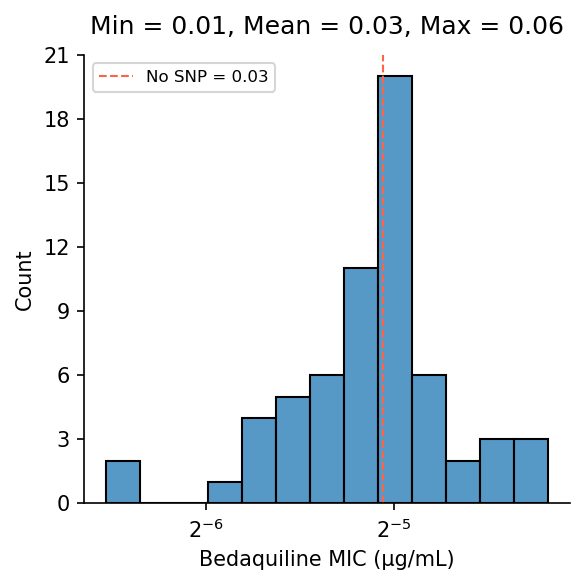

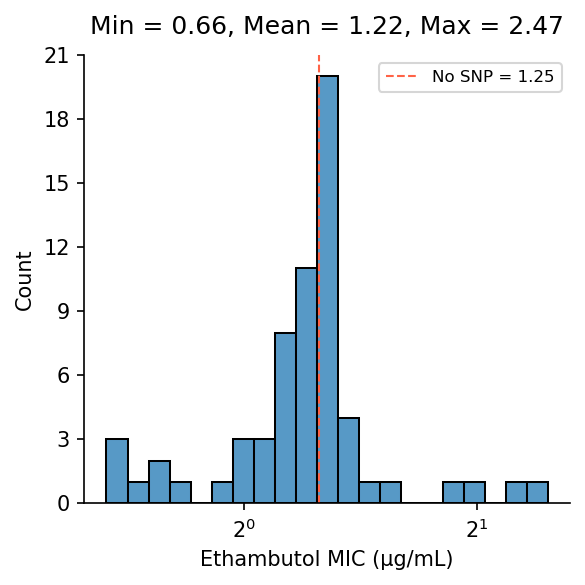

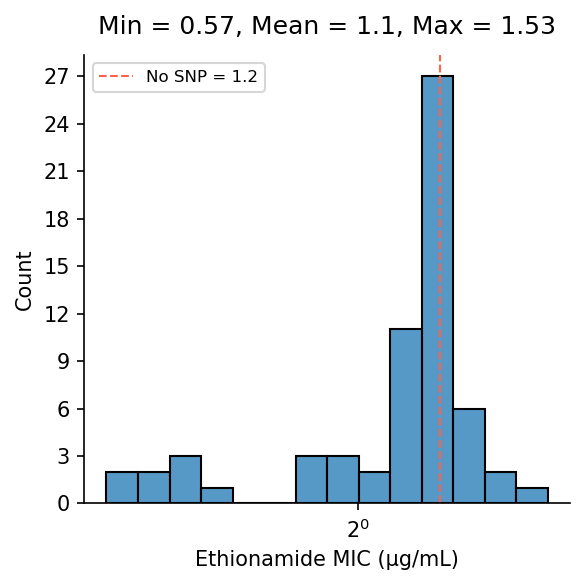

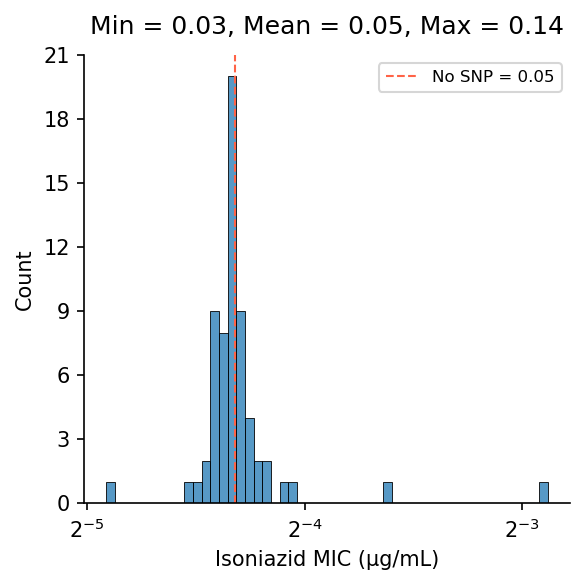

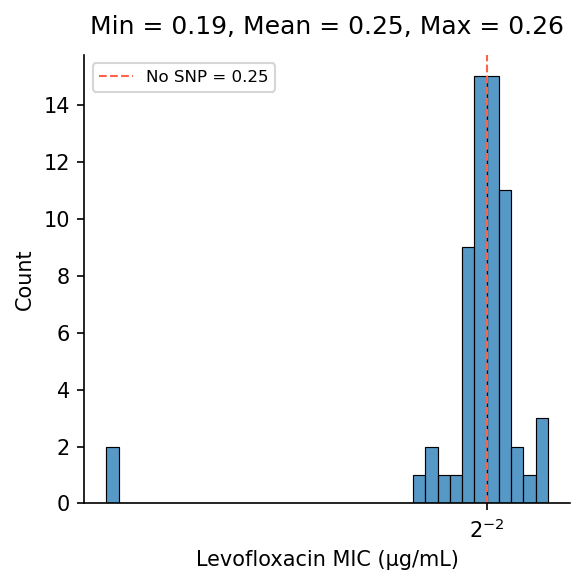

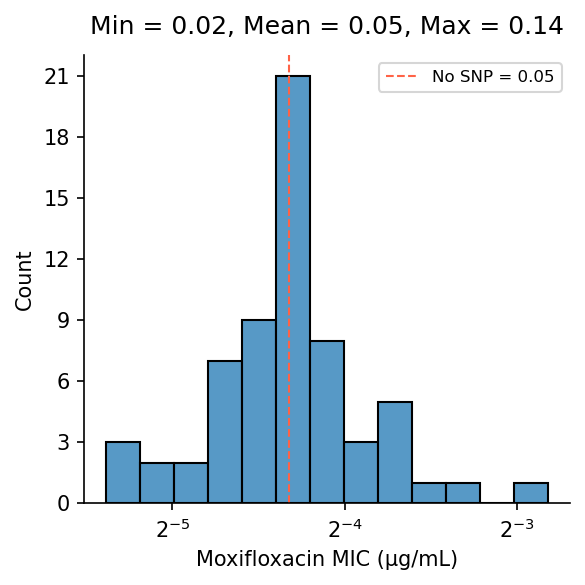

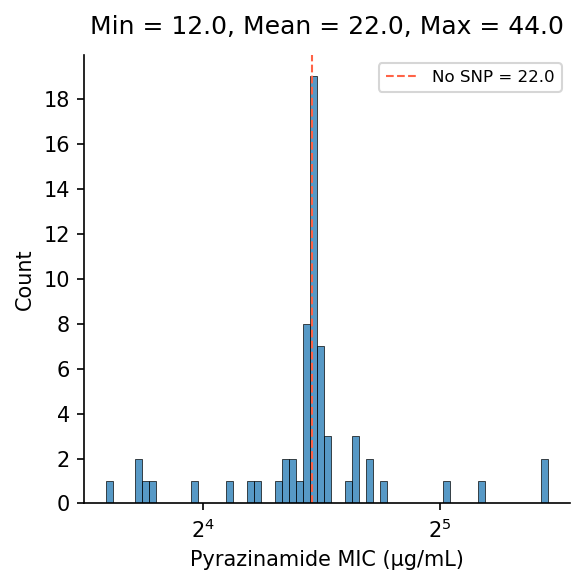

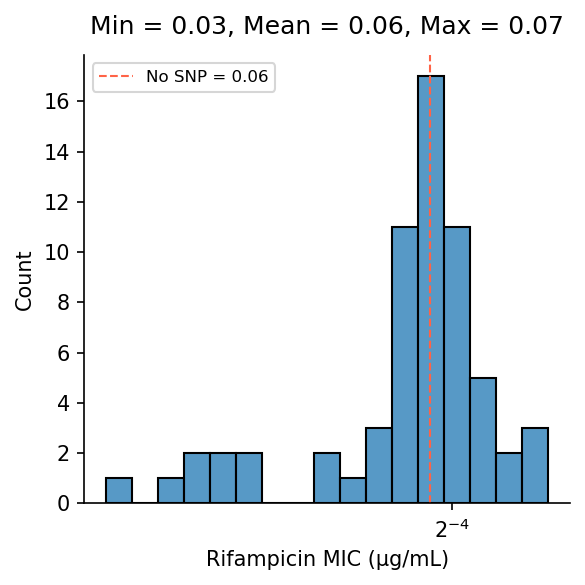

In [22]:
all_drugs_lineage_SNP_predictions = {}

for drug in os.listdir(data_dir):
    try:
        # if drug == 'PZA':
        #     log_base = 10
        # else:
        #     log_base = 2
        log_base = 2
            
        all_drugs_lineage_SNP_predictions[drug] = plot_insilico_lineage_pred(drug, log_base=log_base, )#save_fName=f"results/{abbr_drug_dict[drug]}/lineage_SNP_predictions.svg")
    except:
        print(f"{drug} not finished")